
**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update the portfolio index link to your own work once completed!

# Topic project 4.1 Applying NLP for topic modelling in a real-life context

Applying NLP for topic modelling is crucial for data analysis in business because it enables companies to identify and understand key themes and patterns within large volumes of text data. This efficiency allows businesses to extract essential insights and trends without manually sifting through extensive documents. Automated topic modelling helps businesses make informed decisions faster, which helps to improve productivity and gain a competitive edge. Additionally, it supports better information management by uncovering underlying topics in reports, emails, customer feedback, and market research, which enhances overall business intelligence and strategic planning.

## **Business context**

The PureGym Group, founded in 2008, has approximately 2 million members and 600 gyms across the world (particularly in the UK, Denmark, and Switzerland). As one of the world’s largest value fitness operators, PureGym appeals to a broad range of customers by offering high-quality, low-cost, and flexible fitness facilities. The company’s customer-centric proposition – affordable membership fees, no fixed-term contracts, and 24/7 access to high-quality gyms – differentiates it from more traditional gyms and elevates it as a market leader within this space.

This focus on the customer is centred on wanting to understand what motivates members to join and what factors influence their behaviours once they have joined. Understanding how to leverage innovative technology to influence, improve, and simplify their experience allows PureGym to foster an open, welcoming, and diverse environment for its members while maintaining the value proposition that PureGym is built upon.

With the shift in focus to value-for-money memberships across the gym industry, PureGym seeks to achieve its mission of ‘inspiring a healthier world by providing members with affordable access to the benefits being healthy can offer’.

## **Objective**

In the Notebook, I will:

- Use two data sets containing customer reviews from Google and Trustpilot.
- Perform basic level analysis by finding the frequently used words in both data sets.
- Generate a wordcloud to visualise the most frequently used words in the reviews.
- Apply BERTopic for topic modelling, keeping track of gym locations, to identify common topics and words in the negative reviews.
- Identify the locations that have the most negative reviews.
- Use the built-in visualisation functions in BERTopic to cluster and visually represent the topics and words in these reviews, thereby helping to identify specific themes from the reviews.
- Conduct a comparison with Gensim’s LDA model to validate the topic modelling results.
- Perform emotion analysis to identify the emotions associated with customer reviews.
- Filter out angry reviews and apply BERTopic to discover prevalent topics and words being discussed these negative reviews.
- Leverage the multi-purpose capability of the state-of-the-art models, with the help of prompts, to identify top topics in each review.
- Use a different prompt with the Falcon-7b-instruct model to further generate suggestions for improvements for PureGym, based on the top topics identified from the negative reviews.

# Data Import:

In [ ]:
import warnings
import os
import logging

# Suppress standard warnings
warnings.filterwarnings('ignore')

# Suppress warnings via environment variable
os.environ['PYTHONWARNINGS'] = 'ignore'

# Aggressively intercept and silence all background warnings (like the jupyter_client DeprecationWarning)
def suppress_all_warnings(message, category, filename, lineno, file=None, line=None):
    pass

warnings.showwarning = suppress_all_warnings

# Also silence jupyter_client logger just in case
logging.getLogger('jupyter_client').setLevel(logging.ERROR)

In [ ]:
# Installations.

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download("wordnet")

# Bertopic

!pip install bertopic
!pip install langid
!pip install rapidfuzz
!pip install pyLDAvis

# Python package for local LLM access.

!pip install ollama

# System dependencies for Ollama / model runtime.

!sudo apt-get update && sudo apt-get install -y zstd
!curl -fsSL https://ollama.ai/install.sh | sh

# Environment configuration.

import os
os.environ.update({'LD_LIBRARY_PATH': '/usr/lib64-nvidia'})

# Start Ollama and pull model.

!nohup ollama serve &
!ollama pull phi4-mini
!ollama list

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 177, in make_resolver
    return pip._internal.resolution.resolvelib.resolver.Resolver(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 58, in __init__
    self.factory = Factory(
                   ^^^^^^^^
  File "/usr/local/lib/py

In [ ]:
# Core Data Handling.

import pandas as pd
import numpy as np

# Text Processing.

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.wordnet import WordNetLemmatizer

# Language Detection and Fuzzy Matching.

import langid
from rapidfuzz import process

# Visualisation.

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px

# Topic Modelling: BERTopic.

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from hdbscan import HDBSCAN

# Transformer Models.

import torch
from transformers import pipeline

# Geolocation.

from geopy.geocoders import Nominatim
import time

# Local LLM: Ollama.

import ollama
from ollama import Client

# Topic Modelling: Gensim LDA.

from gensim import corpora
from gensim.models.ldamodel import LdaModel

# LDA Visualisation.

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Utilities.

import json
import ast
from collections import Counter

# Google Colab.

from google.colab import drive

Initialising a local Ollama client to send and receive LLM requests via the locally hosted model server.

In [ ]:
# Initialise a client.

import ollama
from ollama import Client
client = Client(host="http://localhost:11434", timeout=600)

In [ ]:
# Seed for notebook.

seed = 0

Mounting Google Drive, loading the review datasets from specified file paths, and performing initial validation and structural checks on the data.

In [ ]:
# Mount Google Drive

drive.mount('/content/drive')

# Folder containing the Excel files

base_path = "/content/drive/MyDrive/puregym_data"

# File paths

google_file = f"{base_path}/Google_12_months.xlsx"
trustpilot_file = f"{base_path}/Trustpilot_12_months.xlsx"

# Check folder and files

print("Files in folder:", os.listdir(base_path))
assert os.path.exists(google_file), "Google_12_months.xlsx not found"
assert os.path.exists(trustpilot_file), "Trustpilot_12_months.xlsx not found"

# Load datasets

google_raw = pd.read_excel(google_file)
trustpilot_raw = pd.read_excel(trustpilot_file)

# Basic checks

print("Google shape:", google_raw.shape)
print("Trustpilot shape:", trustpilot_raw.shape)
print("\nGoogle columns:")
print(google_raw.columns.tolist())
print("\nTrustpilot columns:")
print(trustpilot_raw.columns.tolist())

Mounted at /content/drive
Files in folder: ['Google_12_months.xlsx', 'Trustpilot_12_months.xlsx']
Google shape: (23250, 7)
Trustpilot shape: (16673, 15)

Google columns:
['Customer Name', 'SurveyID for external use (e.g. tech support)', "Club's Name", 'Social Media Source', 'Creation Date', 'Comment', 'Overall Score']

Trustpilot columns:
['Review ID', 'Review Created (UTC)', 'Review Consumer User ID', 'Review Title', 'Review Content', 'Review Stars', 'Source Of Review', 'Review Language', 'Domain URL', 'Webshop Name', 'Business Unit ID', 'Tags', 'Company Reply Date (UTC)', 'Location Name', 'Location ID']


In [ ]:
# Inspect the google review data.

display(google_raw.head(5))

,Customer Name,SurveyID for external use (e.g. tech support),Club's Name,Social Media Source,Creation Date,Comment,Overall Score
0,**,ekkt2vyxtkwrrrfyzc5hz6rk,Leeds City Centre North,Google Reviews,2024-05-09 23:49:18,NaN,4
1,**,e9b62vyxtkwrrrfyzc5hz6rk,Cambridge Leisure Park,Google Reviews,2024-05-09 22:48:39,Too many students from two local colleges go h...,1
2,**,e2dkxvyxtkwrrrfyzc5hz6rk,London Holborn,Google Reviews,2024-05-09 22:08:14,"Best range of equipment, cheaper than regular ...",5
3,**,e3tfxvyxtkwrrrfyzc5hz6rk,Cheshunt Brookfield Shopping Park,Google Reviews,2024-05-09 21:58:07,"Good gym when it’s not busy, tend to get too b...",4
4,**,edkrxvyxtkwrrrfyzc5hz6rk,Bristol Union Gate,Google Reviews,2024-05-09 21:48:00,"(current member)\n\nGym is quite dirty, more o...",1


In [ ]:
# Inspect the trustpilot review data.

display(trustpilot_raw.head(5))

,Review ID,Review Created (UTC),Review Consumer User ID,Review Title,Review Content,Review Stars,Source Of Review,Review Language,Domain URL,Webshop Name,Business Unit ID,Tags,Company Reply Date (UTC),Location Name,Location ID
0,663d40378de0a14c26c2f63c,2024-05-09 23:29:00,663d4036d5fa24c223106005,A very good environment,A very good environment,5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,2024-05-10 08:12:00,Solihull Sears Retail Park,7b03ccad-4a9d-4a33-9377-ea5bba442dfc
1,663d3c101ccfcc36fb28eb8c,2024-05-09 23:11:00,5f5e3434d53200fa6ac57238,I love to be part of this gym,I love to be part of this gym. Superb value fo...,5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,2024-05-10 08:13:00,Aylesbury,612d3f7e-18f9-492b-a36f-4a7b86fa5647
2,663d375859621080d08e6198,2024-05-09 22:51:00,57171ba90000ff000a18f905,Extremely busy,"Extremely busy, no fresh air.",1,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,NaT,Sutton Times Square,0b78c808-f671-482b-8687-83468b7b5bc1
3,663d4fa1f25670a3339ccf6d,2024-05-09 22:35:00,663d4fa0d5fa24251d1068e7,Great vibes,"Great vibes, fantastic gym",5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,NaT,London Finchley,bc3a9a8c-defe-47b3-8ee6-f73a03b7447e
4,663d3251d8367b7b3c4ace64,2024-05-09 22:30:00,60c20598384d84001a4250de,Everything it needs to be,"Clean, well managed, classes are good.",5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,2024-05-10 08:14:00,Crayford,9ce470b7-57df-4533-af2f-c539422fed14


# Cleansing both datasets:

Standardising location text by lowercasing, removing punctuation, and normalising whitespace for consistent matching.

In [ ]:
# Define basic cleaning function for locations.

def clean_location(x):
    x = str(x).lower()
    x = re.sub(r'[^a-z0-9\s]', '', x)   # remove punctuation
    x = re.sub(r'\s+', ' ', x).strip()  # normalise spaces
    return x

Standardising review text by lowercasing, removing URLs, HTML, non-text characters, and normalising whitespace.

In [ ]:
# Define basic cleaning function for reviews.

def clean_review_basic(text):
    # Ensure string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Removes standalone numbers only.
    text = re.sub(r'\b\d+\b', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove emojis / non-text.
    text = re.sub(r'[^\w\s.,!?]', '', text)

    # Remove extra whitespace.
    text = re.sub(r'\s+', ' ', text).strip()

    return text

## Google: Data Cleaning

Detecting the language of each review and flagging non-English entries for exclusion from analysis.

In [ ]:
# Drop reviews in foreign languages.

def detect_lang_fast(text):
    if pd.isna(text) or str(text).strip() == "":
        return None
    return langid.classify(text)[0]

google_raw["lang"] = google_raw["Comment"].apply(detect_lang_fast)

In [ ]:
# Check for instances.

print(google_raw["lang"].unique())

print(google_raw["lang"].value_counts())

[None 'en' 'da' 'ar' 'pl' 'mt' 'la' 'de' 'zh' 'es' 'it' 'el' 'vi' 'pt'
 'ja' 'ga' 'gl' 'ru' 'fr' 'no' 'bn' 'hr' 'ko' 'sl' 'nl' 'sv' 'cy' 'et'
 'he' 'am' 'be' 'lb' 'fi' 'eu' 'ca' 'nn' 'si' 'nb' 'hy' 'af' 'ta' 'cs'
 'lt' 'wa' 'sk' 'hi' 'lv' 'mg' 'uk' 'tr' 'hu' 'jv' 'ro' 'dz' 'mk' 'tl'
 'se' 'bs']
lang
en    12354
de      447
da      423
fr      103
es       77
pl       61
zh       50
it       44
nl       43
no       36
ja       35
la       22
pt       18
sv       17
ru       17
ko       12
mt       11
he       11
ar        9
gl        7
hr        7
ca        7
sl        6
cy        5
nb        5
af        5
lt        4
bn        4
vi        4
hu        4
lb        4
et        4
am        4
sk        3
ro        3
fi        3
eu        3
cs        3
ga        2
hi        2
tr        2
mg        2
el        1
ta        1
si        1
be        1
hy        1
nn        1
wa        1
uk        1
lv        1
jv        1
dz        1
mk        1
tl        1
se        1
bs        1
Name: count, dt

Identifying English as the dominant language in the dataset, with a long tail of low-frequency non-English reviews subsequently excluded to improve NLP consistency.

In [ ]:
# Drop languages other than English.

google_en = google_raw[google_raw["lang"] == "en"]

In [ ]:
# Drop useless columns for google dataset.

useless_columns_google = ['Customer Name',
                          'SurveyID for external use (e.g. tech support)',
                          'Social Media Source']

google_df = google_en.drop(columns=useless_columns_google)
display(google_df.head(20))

,Club's Name,Creation Date,Comment,Overall Score,lang
1,Cambridge Leisure Park,2024-05-09 22:48:39,Too many students from two local colleges go h...,1,en
2,London Holborn,2024-05-09 22:08:14,"Best range of equipment, cheaper than regular ...",5,en
3,Cheshunt Brookfield Shopping Park,2024-05-09 21:58:07,"Good gym when it’s not busy, tend to get too b...",4,en
4,Bristol Union Gate,2024-05-09 21:48:00,"(current member)\n\nGym is quite dirty, more o...",1,en
7,New Barnet,2024-05-09 20:16:04,This gym is way too hot to even workout in. Th...,2,en
9,Glasgow Robroyston,2024-05-09 19:15:22,I live local to puregym and have been going fo...,4,en
12,Sunderland,2024-05-09 18:24:48,It's has been a nice experience to get some ex...,5,en
15,"115 - Dannebrogsgade, Aalborg",2024-05-09 17:43:37,If a lot of people go and sometimes you have t...,3,en
17,Hatfield,2024-05-09 17:24:05,"Best gym ever I visited , with great equipment...",5,en
18,Sheffield Millhouses,2024-05-09 17:13:57,Very nice and organised gym with good staff,5,en


Checking for duplicate reviews and removing them to ensure each observation is unique prior to analysis.

In [ ]:
# Check for duplicates in the data.

print(f"Duplicate Reviews: {google_df.duplicated().sum()}")

# Drop duplicates.

google_df = google_df.drop_duplicates()
print(f"After Cleansing: {google_df.duplicated().sum()}")

Duplicate Reviews: 0
After Cleansing: 0


In [ ]:
# Inspect data and datatypes.

print(google_df.info(), '\n')

print(google_df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 12354 entries, 1 to 23248
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Club's Name    12354 non-null  object        
 1   Creation Date  12354 non-null  datetime64[ns]
 2   Comment        12354 non-null  object        
 3   Overall Score  12354 non-null  int64         
 4   lang           12354 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 579.1+ KB
None 

                       Creation Date  Overall Score
count                          12354   12354.000000
mean   2023-10-28 02:03:36.954670848       3.937915
min              2022-03-07 20:36:21       1.000000
25%    2023-08-16 14:40:57.249999872       3.000000
50%              2023-11-25 02:46:17       5.000000
75%    2024-02-21 14:07:22.750000128       5.000000
max              2024-05-09 22:48:39       5.000000
std                              NaN       1.4

Assessing data completeness by summarising null counts and confirming no missing values across the dataset.

In [ ]:
# Create missing values summary table.

missing_summary_g = pd.DataFrame({
    "column": google_df.columns,
    "null_count": google_df.isna().sum().values})

# Add percentage column.

missing_summary_g["null_percentage"] = (
    missing_summary_g["null_count"] / len(google_df) * 100).round(2)

# Sort by highest missing %.

missing_summary_g = missing_summary_g.sort_values(by="null_percentage", ascending=False)

print(missing_summary_g)

          column  null_count  null_percentage
0    Club's Name           0              0.0
1  Creation Date           0              0.0
2        Comment           0              0.0
3  Overall Score           0              0.0
4           lang           0              0.0


In [ ]:
# Drop rows with missing comments.

google_df = google_df.dropna(subset=['Comment'])
print(google_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 12354 entries, 1 to 23248
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Club's Name    12354 non-null  object        
 1   Creation Date  12354 non-null  datetime64[ns]
 2   Comment        12354 non-null  object        
 3   Overall Score  12354 non-null  int64         
 4   lang           12354 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 579.1+ KB
None


Cleaning the review and location strings.

In [ ]:
# Clean club location.

google_df['Club_clean'] = google_df['Club\'s Name'].apply(clean_location)

# Clean review column.

google_df['Comment_clean'] = google_df['Comment'].apply(clean_review_basic)

Standardising the dataset.

In [ ]:
# Standardise column names: 'Location', 'Stars', 'Review', 'Date'.

google_clean = google_df.copy()

google_clean['Location'] = google_clean['Club_clean']
google_clean['Stars'] = google_clean['Overall Score']
google_clean['Review'] = google_clean['Comment_clean']
google_clean['Date'] = google_clean['Creation Date']

google_clean = google_clean.drop(columns=['Club_clean', 'Club\'s Name', 'Overall Score', 'Comment', 'Comment_clean', 'Creation Date','lang'])

Performing safety checks on missing values.

In [ ]:
# Current rows.

print(f"Current rows: {len(google_clean)}")

Current rows: 12354


In [ ]:
# Drop empty rows using boolean indexing.
google_clean = google_clean[
    ~(google_clean['Review'].isna()) &
    ~(google_clean['Review'].str.strip() == '')
]

# Final check.
check_rows = google_clean[
    google_clean['Review'].isna() |
    (google_clean['Review'].str.strip() == '')
]

print(check_rows, '\n')

print(f"Rows after cleansing: {len(google_clean)}")

Empty DataFrame
Columns: [Location, Stars, Review, Date]
Index: [] 

Rows after cleansing: 12354


In [ ]:
# Inspect the dataset's unique values.

print(f"Unique Locations: {google_clean['Location'].nunique()}",'\n')
print(google_clean['Location'].unique())

Unique Locations: 468 

['cambridge leisure park' 'london holborn'
 'cheshunt brookfield shopping park' 'bristol union gate' 'new barnet'
 'glasgow robroyston' 'sunderland' '115 dannebrogsgade aalborg' 'hatfield'
 'sheffield millhouses' 'manchester cheetham hill' 'london north finchley'
 'milton keynes kingston centre' 'newcastle eldon garden' 'airdrie'
 'staines' 'cardiff central' 'bangor wales' 'northampton central'
 'west bromwich' 'stafford' 'lincoln carlton centre'
 'colchester retail park' 'london oval' 'cambridge grafton centre'
 'merthyr tydfil' 'norwich castle mall' 'rochdale' 'aylesbury'
 'liverpool kirkby' 'nottingham beeston' 'london enfield' 'coleraine'
 '279 sct jrgens park nstved' 'leicester st georges way' 'epsom'
 'galashiels' 'salford' 'altrincham' 'southampton shirley'
 'broadstairs westwood gateway retail park' 'loughborough'
 'london woolwich' 'leeds hunslet' 'coventry skydome'
 'glasgow bath street' 'brighton london road' 'london holloway road'
 'redditch ringway'

There are 512 unique locations in the Google Review dataset. This is clearly not limited to the UK. For the initial word clouds, I'll leave in the ex-UK locations and ensure they are screened out, when we move to consolidating both datasets.

For clarity, I will standardise column names across both datasets and clean text here.

Initially, cleanse review data without tokenising,
to preserve basic readability. Successive functions will handle tokenisation, and removal of domain specific terminology ('Puregym').

## TrustPilot: Data Cleaning

In [ ]:
# Check for foreign languages.

print(trustpilot_raw['Review Language'].unique())

['en' 'it' 'da' 'pl' 'bg' 'ar' 'pt' 'ro' 'es' 'fr' 'sco' 'sk' 'st' 'de'
 'et' 'sv' 'lt' 'ru' 'uk' 'tr']


Confirming English as the primary language in the second dataset, with a smaller set of additional languages present and subsequently filtered out.

In [ ]:
# Drop reviews in foreign languages.

trustpilot_en = trustpilot_raw[trustpilot_raw['Review Language'] == 'en']

In [ ]:
# Drop useless columns for google dataset.

useless_columns_trustpilot = ['Review ID',
                              'Review Consumer User ID',
                              'Source Of Review',
                              'Review Language',
                              'Domain URL',
                              'Webshop Name',
                              'Business Unit ID',
                              'Tags',
                              'Company Reply Date (UTC)',
                              'Location ID']

trustpilot_df = trustpilot_en.drop(columns=useless_columns_trustpilot)
display(trustpilot_df.head(20))

,Review Created (UTC),Review Title,Review Content,Review Stars,Location Name
0,2024-05-09 23:29:00,A very good environment,A very good environment,5,Solihull Sears Retail Park
1,2024-05-09 23:11:00,I love to be part of this gym,I love to be part of this gym. Superb value fo...,5,Aylesbury
2,2024-05-09 22:51:00,Extremely busy,"Extremely busy, no fresh air.",1,Sutton Times Square
3,2024-05-09 22:35:00,Great vibes,"Great vibes, fantastic gym",5,London Finchley
4,2024-05-09 22:30:00,Everything it needs to be,"Clean, well managed, classes are good.",5,Crayford
5,2024-05-09 22:16:00,Good budget gym,"Good budget gym. Open 24/7. Young, keen and fr...",4,Stirling
6,2024-05-09 22:04:00,It was nice,"It was nice, lowk spacious. I went there for t...",5,NaN
7,2024-05-09 21:52:00,Great gym felt very comfortable enjoyed…,Great gym felt very comfortable enjoyed my ses...,5,Barnstaple
8,2024-05-09 21:46:00,want to know why the code won't let me…,want to know why the code won't let me in. It ...,5,Catford Rushey Green
9,2024-05-09 21:29:00,Fun!,"Fun, worth the work out.",4,London Aldgate


Checking for duplicates.

In [ ]:
# Check for duplicates in the data.

print(f"Before cleansing: {trustpilot_df.duplicated().sum()}")

# Drop duplicates.

trustpilot_df = trustpilot_df.drop_duplicates()

print(f"After cleansing: {trustpilot_df.duplicated().sum()}")

Before cleansing: 0
After cleansing: 0


In [ ]:
# Inspect data and datatypes.

print(trustpilot_df.info(), '\n')

print(trustpilot_df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 16574 entries, 0 to 16672
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Review Created (UTC)  16574 non-null  datetime64[ns]
 1   Review Title          16574 non-null  object        
 2   Review Content        16574 non-null  object        
 3   Review Stars          16574 non-null  int64         
 4   Location Name         11285 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 776.9+ KB
None 

                Review Created (UTC)  Review Stars
count                          16574  16574.000000
mean   2023-12-08 01:15:55.152648960      3.858755
min              2023-05-16 23:05:00      1.000000
25%              2023-10-09 08:15:45      3.000000
50%              2023-12-28 11:07:00      5.000000
75%              2024-03-03 18:10:45      5.000000
max              2024-05-09 23:29:00      5.000000
std  

Assessing data completeness and identifying missing location information as the primary gap, while confirming all core review fields are fully populated.

In [ ]:
# Create missing values summary table.

missing_summary_tp = pd.DataFrame({
    "column": trustpilot_df.columns,
    "null_count": trustpilot_df.isna().sum().values})

# Add percentage column.

missing_summary_tp["null_percentage"] = (
    missing_summary_tp["null_count"] / len(trustpilot_df) * 100).round(2)

# Optional: sort by highest missing %.

missing_summary_tp = missing_summary_tp.sort_values(by="null_percentage", ascending=False)

print(missing_summary_tp)

                 column  null_count  null_percentage
4         Location Name        5289            31.91
0  Review Created (UTC)           0             0.00
1          Review Title           0             0.00
2        Review Content           0             0.00
3          Review Stars           0             0.00


Drop empty locations.

In [ ]:
# Drop rows with missing locations.

trustpilot_df = trustpilot_df.dropna(subset=['Location Name'])
print(trustpilot_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 11285 entries, 0 to 16672
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Review Created (UTC)  11285 non-null  datetime64[ns]
 1   Review Title          11285 non-null  object        
 2   Review Content        11285 non-null  object        
 3   Review Stars          11285 non-null  int64         
 4   Location Name         11285 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 529.0+ KB
None


In [ ]:
# Clean 'Location Name' column.

trustpilot_df["Location_clean"] = trustpilot_df["Location Name"].apply(clean_location)

Because the TrustPilot reviews have both a title and a comment, I will create a function that adds the review title into the comment at the beginning (unless it's already present, so as not to duplicate it).

In [ ]:
# Merge review title and comment unless already present.

def combine_review(row):
    title = str(row["Review Title"]).strip()
    content = str(row["Review Content"]).strip()

    # If title is already in content → just use content
    if title.lower() in content.lower():
        return content

    # Otherwise combine
    return title + ". " + content

trustpilot_df["Review_text"] = trustpilot_df.apply(combine_review, axis=1)

In [ ]:
# View data.

print(trustpilot_df["Review_text"].head(10))

0                               A very good environment
1     I love to be part of this gym. Superb value fo...
2                         Extremely busy, no fresh air.
3                            Great vibes, fantastic gym
4     Everything it needs to be. Clean, well managed...
5     Good budget gym. Open 24/7. Young, keen and fr...
7     Great gym felt very comfortable enjoyed…. Grea...
8     want to know why the code won't let me…. want ...
9                        Fun!. Fun, worth the work out.
16    Ellie PT. Had Ellie as my PT for 4 months befo...
Name: Review_text, dtype: object


In [ ]:
# Clean review column.

trustpilot_df['Review_clean'] = trustpilot_df['Review_text'].apply(clean_review_basic)

In [ ]:
print(trustpilot_df.columns)

Index(['Review Created (UTC)', 'Review Title', 'Review Content',
       'Review Stars', 'Location Name', 'Location_clean', 'Review_text',
       'Review_clean'],
      dtype='object')


Standardising the dataset.

In [ ]:
 # Standardise column names: 'Location', 'Stars', 'Review', 'Date'.

trustpilot_clean = trustpilot_df.copy()

trustpilot_clean['Location'] = trustpilot_clean['Location_clean']
trustpilot_clean['Stars'] = trustpilot_clean['Review Stars']
trustpilot_clean['Review'] = trustpilot_clean['Review_clean']
trustpilot_clean['Date'] = trustpilot_clean['Review Created (UTC)']

trustpilot_clean = trustpilot_clean.drop(columns=['Review Created (UTC)', 'Review Title', 'Review Content',
       'Review Stars', 'Location Name', 'Location_clean', 'Review_text', 'Review_clean'])

In [ ]:
# Display the dataset.

display(trustpilot_clean)

,Location,Stars,Review,Date
0,solihull sears retail park,5,a very good environment,2024-05-09 23:29:00
1,aylesbury,5,i love to be part of this gym. superb value fo...,2024-05-09 23:11:00
2,sutton times square,1,"extremely busy, no fresh air.",2024-05-09 22:51:00
3,london finchley,5,"great vibes, fantastic gym",2024-05-09 22:35:00
4,crayford,5,"everything it needs to be. clean, well managed...",2024-05-09 22:30:00
...,...,...,...,...
16666,ballymena,5,best gym in ballymena. we went for the first t...,2023-05-17 01:06:00
16667,warrington central,5,the staff is in the top 10. good music and a r...,2023-05-17 00:40:00
16668,rushden,4,classes at puregym. i enjoy the classes and th...,2023-05-16 23:30:00
16669,yate,5,"happy and helpful staff, feel very comfortable...",2023-05-16 23:18:00


Final checks after review data has been cleaned.

In [ ]:
# Isolate Review cells that are now empty due to cleaning.

tp_empty_rows = trustpilot_clean[
    trustpilot_clean['Review'].isna() |
    (trustpilot_clean['Review'].str.strip() == '')
]

display(tp_empty_rows)

,Location,Stars,Review,Date
1991,west thurrock,5,,2024-04-08 10:56:00
7216,peterborough serpentine green,5,,2024-01-23 11:07:00
11600,wolverhampton south,5,,2023-10-15 22:12:00
13307,east kilbride,5,,2023-07-21 13:33:00
13374,birmingham maypole,5,,2023-07-19 13:55:00


In [ ]:
# Current rows.

print(f"Current rows: {len(trustpilot_clean)}")

Current rows: 11285


In [ ]:
# Drop empty rows using boolean indexing.
trustpilot_clean = trustpilot_clean[
    ~(trustpilot_clean['Review'].isna()) &
    ~(trustpilot_clean['Review'].str.strip() == '')
]

# Final check.
tp_check_rows = trustpilot_clean[
    trustpilot_clean['Review'].isna() |
    (trustpilot_clean['Review'].str.strip() == '')
]

print(check_rows, '\n')

print(f"Rows after cleansing: {len(trustpilot_clean)}")

Empty DataFrame
Columns: [Location, Stars, Review, Date]
Index: [] 

Rows after cleansing: 11280


In [ ]:
# Inspect the dataset's unique values.

print(f"Unique Locations: {trustpilot_clean['Location'].nunique()}",'\n')
print(trustpilot_clean['Location'].unique())

Unique Locations: 376 

['solihull sears retail park' 'aylesbury' 'sutton times square'
 'london finchley' 'crayford' 'stirling' 'barnstaple'
 'catford rushey green' 'london aldgate' 'hemel hempstead'
 'leeds city centre south' 'london bermondsey' 'west bromwich'
 'broadstairs' 'kirkcaldy' 'durham arnison' 'london muswell hill'
 'chester' 'camberley' 'derby' 'london croydon' 'edinburgh west'
 'llantrisant' 'wolverhampton south' 'nottingham beeston'
 'london swiss cottage' 'widnes' 'manchester first street' 'dunfermline'
 'bristol harbourside' 'london wembley' 'sunderland'
 'birmingham snow hill plaza' 'stokeontrent east' 'dumfries' '345'
 'london seven sisters' 'norwich aylsham road' 'lisburn laganbank'
 'caerphilly' 'south ruislip' 'east grinstead' 'mansfield' 'hull anlaby'
 'colchester retail park' 'cambridge leisure park' 'brighton central'
 'london hayes' 'portsmouth commercial road' 'watford waterfields'
 'oxford central' 'wrexham' 'london sydenham' 'ipswich ravenswood'
 'rochdale

In [ ]:
# Drop '345'.

trustpilot_clean = trustpilot_clean[trustpilot_clean['Location'] != '345']

At a first glance, these locations look almost entirely UK-based.

# Location Analysis:

Identifying overlapping locations across the two datasets using both exact matching and fuzzy string matching to capture inconsistencies in naming conventions.

## Method 1:

100%, word-for-word Matches:

In [ ]:
# Extract locations from the Trustpilot dataframe and convert to a list.

trustpilot_locations = trustpilot_clean['Location'].unique()
trustpilot_locations = trustpilot_locations.astype(str)
trustpilot_locations_sorted = np.sort(trustpilot_locations).tolist()

print("Number of unique Trustpilot locations:", len(trustpilot_locations))

# Extract locations from the Google dataframe.

google_locations = google_clean["Location"].unique()
google_locations = google_locations.astype(str)
google_locations_sorted = np.sort(google_locations).tolist()
print("Number of unique Google locations:", len(google_locations))

# Check overlap between the two datasets.

intersection_of_locations = sorted(list(set(trustpilot_locations) & set(google_locations)))
print("Number of common locations:", len(intersection_of_locations))

Number of unique Trustpilot locations: 375
Number of unique Google locations: 468
Number of common locations: 315


Comparing location coverage across datasets, showing substantial overlap with additional unique locations present in each source due to differences in naming and coverage.

## Method 2:

Fuzzy-matching:

In [ ]:
matches = []

for loc in trustpilot_clean['Location'].unique():
    match, score, _ = process.extractOne(
        loc,
        google_clean['Location'].unique()
    )
    if score > 90:
        matches.append((loc, match, score))

# Convert to DataFrame

matches_df = pd.DataFrame(matches, columns=[
    "trustpilot_location",
    "google_location",
    "similarity_score"

])

# Sort by similarity (highest first)
matches_df = matches_df.sort_values(by="similarity_score", ascending=False)

# Display results
display(matches_df)

# Count
print("Number of matches:", len(matches_df))

,trustpilot_location,google_location,similarity_score
324,edinburgh waterfront,edinburgh waterfront,100.000000
0,aylesbury,aylesbury,100.000000
1,sutton times square,sutton times square,100.000000
2,london finchley,london finchley,100.000000
3,barnstaple,barnstaple,100.000000
...,...,...,...
27,stokeontrent east,stoke on trent east,94.444444
264,stratford upon avon,stratforduponavon,94.444444
165,westonsupermare,weston super mare,93.750000
151,ashtonunderlyne,ashton under lyne,93.750000


Number of matches: 325


Confirming a high degree of alignment between datasets, with exact matches and minor naming variations captured through high-similarity fuzzy matching.

In [ ]:
# Get a list of the locations with similarity scores < 100 & > 90.

less_than_100_matches = matches_df[(matches_df['similarity_score'] < 100) & (matches_df['similarity_score'] > 90)]
display(less_than_100_matches)

,trustpilot_location,google_location,similarity_score
26,birmingham snow hill plaza,birmingham snow hill,95.000000
98,peterborough serpentine green,peterborough serpentine,95.000000
61,aberdeen wellington circle,aberdeen wellington,95.000000
277,edinburgh craigleith id 317,edinburgh craigleith,95.000000
57,chelmsford meadows,chelmsford the meadows,95.000000
27,stokeontrent east,stoke on trent east,94.444444
264,stratford upon avon,stratforduponavon,94.444444
165,westonsupermare,weston super mare,93.750000
151,ashtonunderlyne,ashton under lyne,93.750000
229,knarebsorough,knaresborough,92.307692


Identifying true matches with minor spelling and formatting differences, confirming that discrepancies are driven by naming inconsistencies rather than distinct locations.

In [ ]:
near_matches = []

for loc in trustpilot_clean['Location'].unique():
    match, score, _ = process.extractOne(
        loc,
        google_clean['Location'].unique()
    )
    if 80 <= score < 90:
        near_matches.append((loc, match, score))

# Convert to DataFrame

near_matches_df = pd.DataFrame(near_matches, columns=[
    "trustpilot_location",
    "google_location",
    "similarity_score"
])

# Sort by similarity (highest first)
near_matches_df = near_matches_df.sort_values(by="similarity_score", ascending=False)

# Display results
display(near_matches_df)

# Count
print("Number of near matches (80–90):", len(near_matches_df))

,trustpilot_location,google_location,similarity_score
0,oxford central,oxford templars shopping park,85.500000
1,london ilford,london north finchley,85.500000
2,newcastle st james,st albans,85.500000
3,edinburgh ocean terminal,edinburgh west,85.500000
4,glasgow charing cross,banbury cross,85.500000
6,sheffield city centre south,south ruislip,85.500000
7,reading basingstoke road,reading calcot,85.500000
10,london camberwell southampton way,london holborn,85.500000
9,coventry warwickshire shopping park,cambridge leisure park,85.500000
8,dover,andover,83.333333


Number of near matches (80–90): 11


Similarity scores below 90% seem to be a threshold for valid matches, as is demonstrated by the suggested matches above. Clearly, there are a number of matches that are not being picked up by the first approach because their naming conventions are not 1:1. We can fix this downstream with some wrangling.

In [ ]:
# Print non-overlapping firms from both datasets.

for loc in trustpilot_locations_sorted:
    if loc not in google_locations_sorted:
        print(loc)

for loc in google_locations_sorted:
    if loc not in trustpilot_locations_sorted:
        print(loc)

398
aberdeen wellington circle
aldershot westgate retail park
ashford warren retail park
ashtonunderlyne
ballymena
banbury cross retail park
birmingham snow hill plaza
borehamwood
broadstairs
camden
canterbury riverside
catford rushey green
chelmsford meadows
chippenham
cirencester retail park
coventry warwickshire shopping park
crayford
crewe grand junction
doncaster
dover
edinburgh craigleith id 317
edinburgh ocean terminal
glasgow charing cross
glasgow silverburn
grantham discovery retail park
gravesend
haverhill
hull anlaby
inverness inshes retail park
knarebsorough
lincoln
llantrisant
london camberwell southampton way
london ilford
london shoreditch
luton and dunstable
macclesfield silk road
maldon blackwater retail park
newcastle st james
newtownabbey
oxford central
palmers green
peterborough serpentine green
reading basingstoke road
redditch
sheffield city centre south
solihull sears retail park
st ives
stevenage
stirling
stokeontrent east
stratford upon avon
taunton riverside
t

Identifying non-overlapping locations across datasets, highlighting primarily non-UK sites and coverage differences between sources.

# Word Clouds:

## Initial Word Clouds:

With the full datasets.

Cleaning and tokenising review text to generate reproducible word-frequency bar charts and word clouds for exploratory text analysis. In the preliminary frequency distribution charts and word clouds, we use the full review set - before focusing on the negative reviews.

In [ ]:
"""
Create a custom function that cleans and tokenises review text.
Plots distribution of word frequencies and visualises them.
Creates word cloud.
"""

def word_cloud_display(df, key, domain_stopwords, top_n=10):

    all_reviews = df[key].dropna().astype(str).str.lower().str.cat(sep=' ')
    all_text = re.sub(r'[^a-z\s]+', ' ', all_reviews)

    stop_words = set(stopwords.words('english'))

    all_stopwords = stop_words.union(domain_stopwords)

    word_tokens = word_tokenize(all_text)

    cleaned_words = [
        word for word in word_tokens
        if word not in all_stopwords
        and len(word) > 2
        and not word.isnumeric()
    ]

    word_distribution = nltk.FreqDist(cleaned_words)
    reviews_word_frequency_distribution_df = pd.DataFrame(
        word_distribution.most_common(top_n),
        columns=["Word", "Frequency"]
    )

    # Plot bar chart
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    sns.barplot(
        data=reviews_word_frequency_distribution_df,
        x="Word",
        y="Frequency"
    )
    plt.title(f"Top {top_n} Words in {key}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Plot word cloud
    plt.figure(figsize=(12, 8))
    wc = WordCloud(
        background_color="black",
        max_words=1000,
        max_font_size=50,
        random_state=seed
    )
    wc.generate(' '.join(cleaned_words))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {key}")
    plt.show()

Removing domain-specific terms (e.g. “gym”, “member”) to reduce noise and surface more meaningful, descriptive insights from the review text.

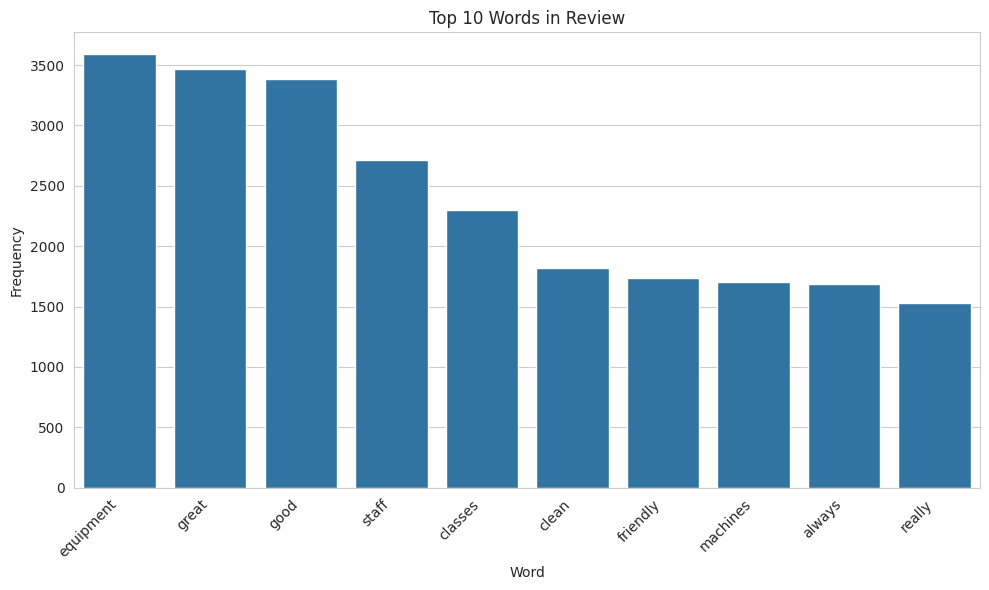

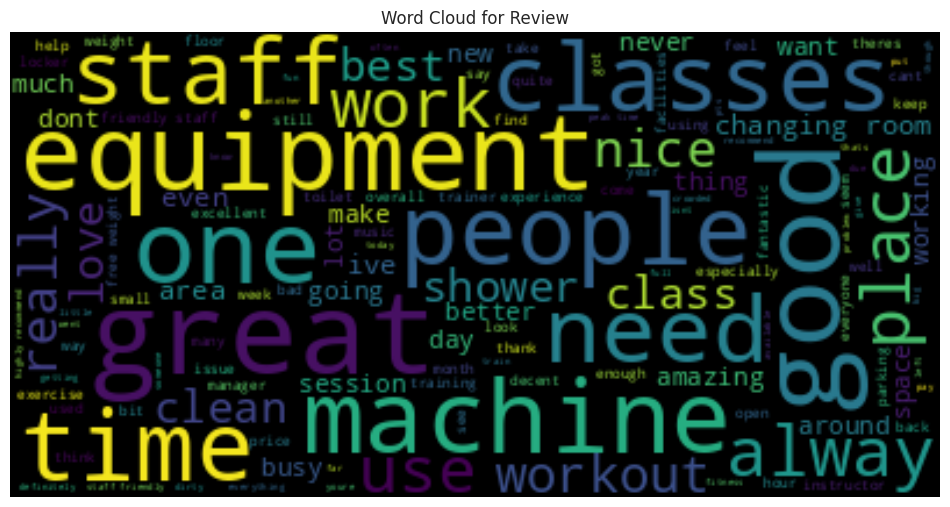

In [ ]:
# Apply function to Google Review dataset.

domain_stopwords = {"puregym", "pure", "gym", "gyms",
                    "member", "members", "membership"
                    }

word_cloud_display(google_clean, "Review", domain_stopwords, top_n=10)

The word cloud from the full Google review set is relatively generic, dominated by broad, high-frequency terms such as “good”, “great”, “staff”, and “equipment,” which provide limited diagnostic insight. This suggests that aggregate review text is too diffuse and sentiment-heavy to clearly surface specific operational issues without further filtering (e.g. focusing on negative reviews).

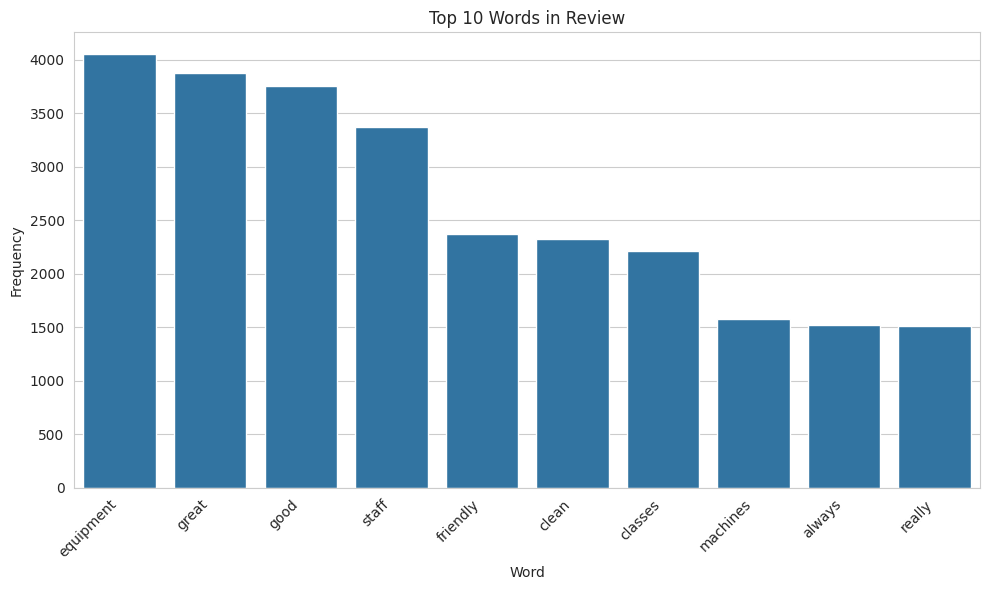

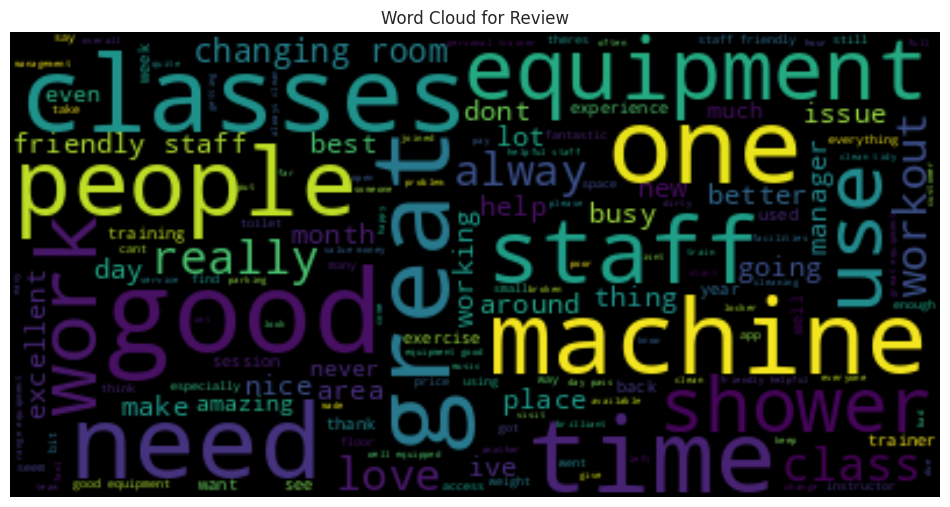

In [ ]:
# Apply function to TrustPilot Review dataset.

word_cloud_display(trustpilot_clean, "Review", domain_stopwords, top_n=10)

Trustpilot reviews have very similiar frequency distributions. Aggregate review text is similarly generic.

Let's see how screening out some more generic words (like good & great) effects the word cloud and frequency distribution.

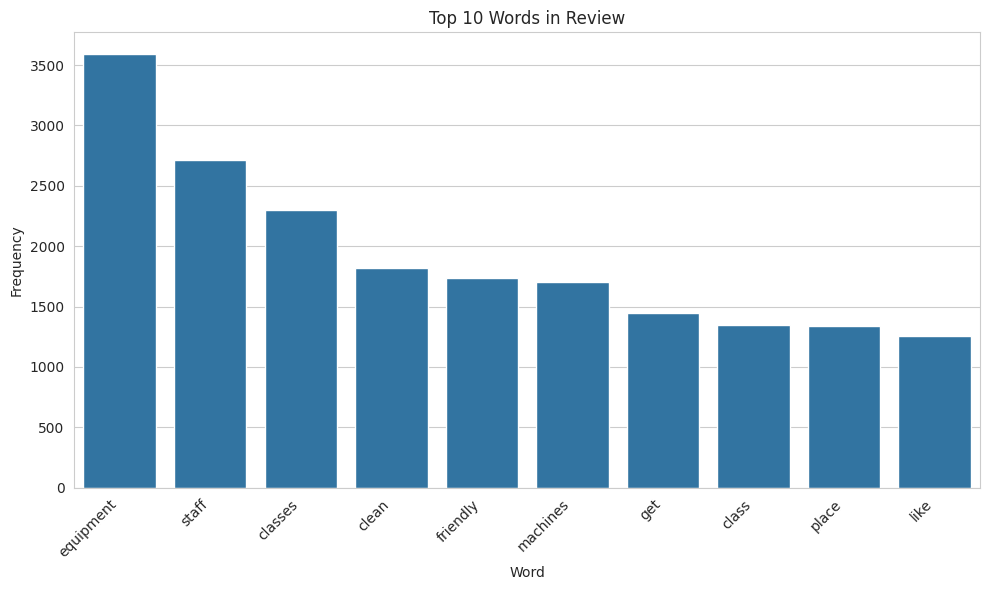

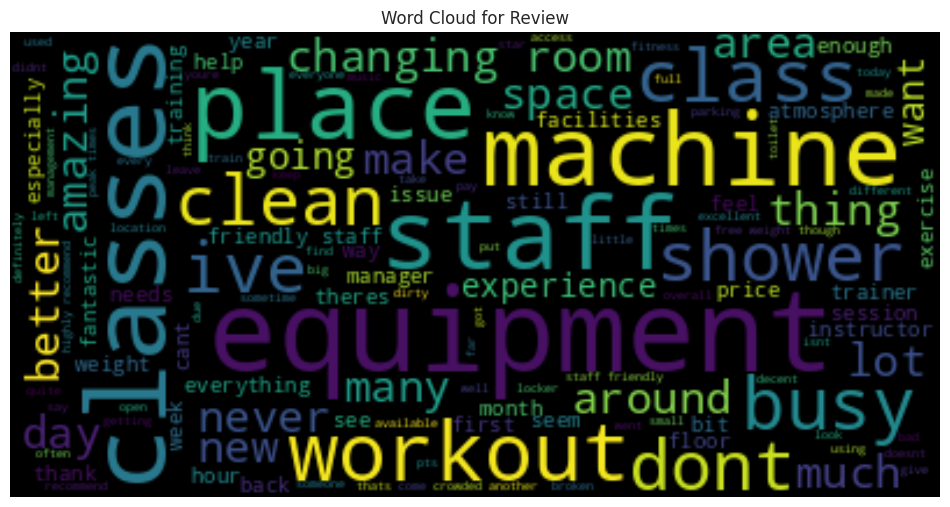

In [ ]:
specific_domain_stopwords = {
    # brand / obvious
    "puregym", "pure", "gym", "gyms",
    "member", "members", "membership",

    # generic sentiment
    "good", "great", "nice", "love", "best",
    "really", "always",

    # filler / low-signal
    "one", "time", "use", "even", "need",

    # borderline (decide based on objective)
    "people", "work", "working"
}

# Apply to google.

word_cloud_display(google_clean, "Review", specific_domain_stopwords, top_n=10)

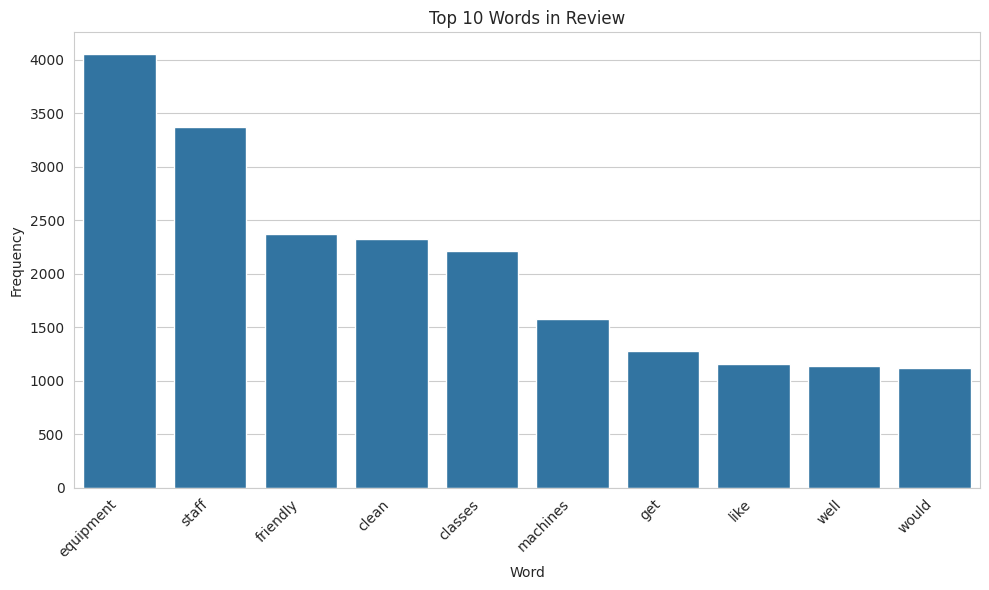

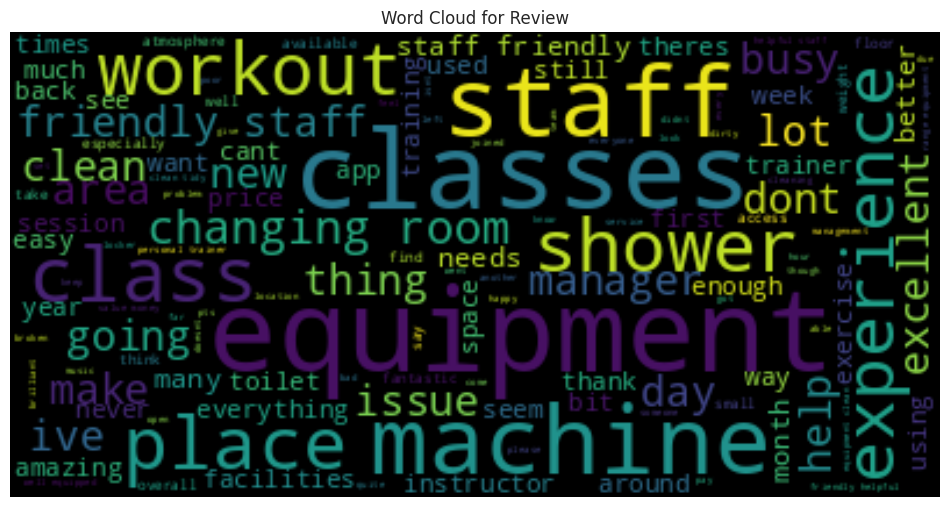

In [ ]:
# Apply to TrustPilot.

word_cloud_display(trustpilot_clean, "Review", specific_domain_stopwords, top_n=10)

After removing generic and domain-specific terms, the word cloud becomes more operationally focused, with clearer signals around equipment, staff, classes, cleanliness, and machines. While still relatively high-level, the outputs now begin to highlight tangible areas of customer experience (e.g. facilities, service, and maintenance), indicating a shift from vague sentiment to more actionable themes.

## Negative Word Clouds:

For reviews with < 3 stars.

Filtering for 1–2 star reviews to isolate negative sentiment, enabling a more focused analysis of underlying issues compared to the broader review set.

In [ ]:
# Create new dataframes that filter out reviews above 2 stars.

negative_reviews_google = google_clean[google_clean['Stars'] < 3]
negative_reviews_trustpilot = trustpilot_clean[trustpilot_clean['Stars'] < 3]

print("Google negative reviews:", negative_reviews_google.shape)
print("Trustpilot negative reviews:", negative_reviews_trustpilot.shape)

Google negative reviews: (2453, 4)
Trustpilot negative reviews: (2202, 4)


In [ ]:
# Display negative reviews.

display(negative_reviews_google)

,Location,Stars,Review,Date
1,cambridge leisure park,1,too many students from two local colleges go h...,2024-05-09 22:48:39
4,bristol union gate,1,"current member gym is quite dirty, more often ...",2024-05-09 21:48:00
7,new barnet,2,this gym is way too hot to even workout in. th...,2024-05-09 20:16:04
19,manchester cheetham hill,2,no access for wc . empty and no assistance to ...,2024-05-09 17:03:50
29,newcastle eldon garden,2,after being at this gym for over a year im fin...,2024-05-09 08:38:07
...,...,...,...,...
23229,london leytonstone,2,"equipment 710 theyre pretty good, over the yea...",2022-03-07 20:57:03
23233,london bermondsey,2,alright for the price. some members are a bit ...,2022-03-07 20:57:02
23234,bristol union gate,1,"disorganised, cramped, and untidy. the old fre...",2022-03-07 20:57:02
23235,bristol union gate,1,"music always too loud, especially when cycling...",2022-03-07 20:57:02


In [ ]:
# Display negative reviews.

display(negative_reviews_trustpilot)

,Location,Stars,Review,Date
2,sutton times square,1,"extremely busy, no fresh air.",2024-05-09 22:51:00
19,leeds city centre south,2,the mens changing rooms smell bad. they need a...,2024-05-09 18:09:00
48,dunfermline,1,no one was cleaning the equipment after. no on...,2024-05-09 09:16:00
51,bristol harbourside,1,not the best experience at 7am on a. not the b...,2024-05-09 08:03:00
55,birmingham snow hill plaza,2,instructor noshow on first day. i signed up fo...,2024-05-09 00:35:00
...,...,...,...,...
16641,colchester retail park,2,"not enough weight plates for benches, spent ha...",2023-05-17 19:13:00
16642,doncaster,1,waiting for equipment is ridiculous. i havent ...,2023-05-17 18:34:00
16643,cardiff gate,2,a sheep dip would be cleaner than your showers...,2023-05-17 17:50:00
16647,sheffield millhouses,2,millhouses. sheffield. showers not warm enough...,2023-05-17 16:40:00


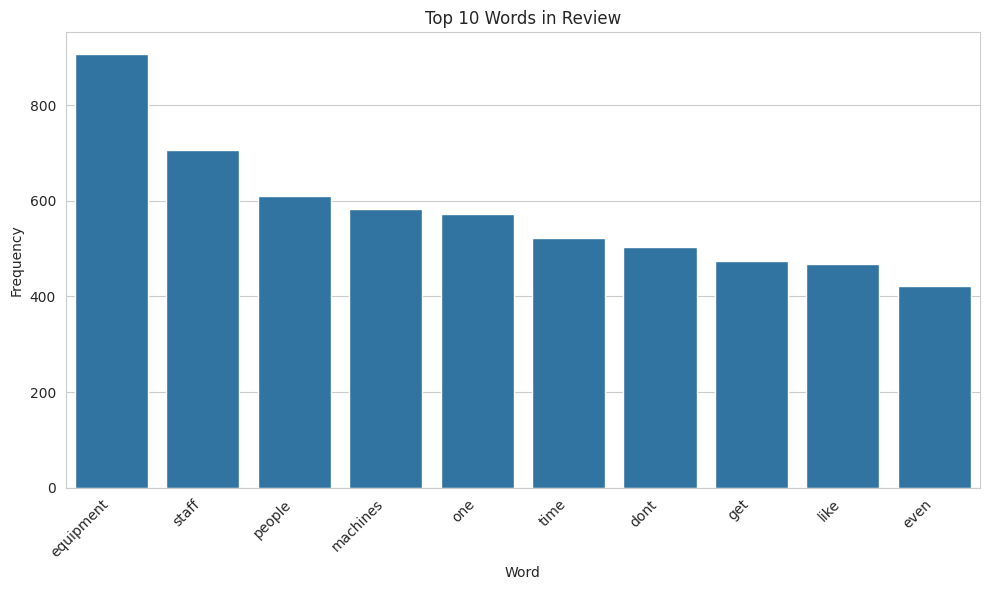

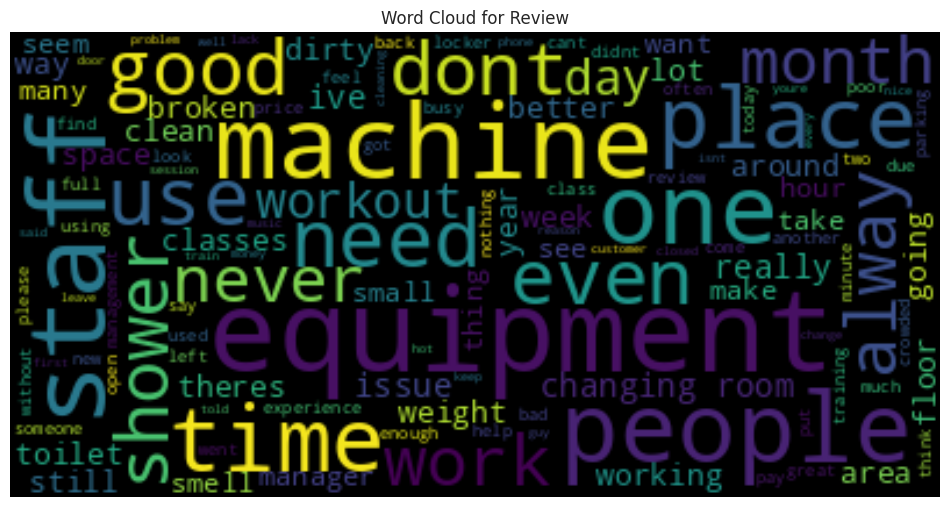

In [ ]:
# Apply to negative Google reviews.

word_cloud_display(negative_reviews_google, "Review", domain_stopwords, top_n=10)

It's really interesting that the word 'good' is still of high frequency when it comes to the negative reviews. Let's isolate some reviews where good is being used alongside negative sentiment to get an idea for what this might entail.

In [ ]:
# Create and display a dataframe for negative reviews containing the word good.

odd_reviews_google = negative_reviews_google[negative_reviews_google['Review'].str.contains('good', case=False)]

display(odd_reviews_google[['Stars', 'Review']])

,Stars,Review
4,1,"current member gym is quite dirty, more often ..."
145,2,"used to be a good gym, a manager clearly decid..."
263,2,not that good
276,2,it was some time ago when i was using this gym...
336,2,this gym is ultimately the reason i withdrew f...
...,...,...
23122,1,surprisingly pretty good inside changing revie...
23149,1,i have cancelled my membership following the c...
23156,2,signed up and joined today. i was really impre...
23215,2,can be busy sometimes. best time to training i...


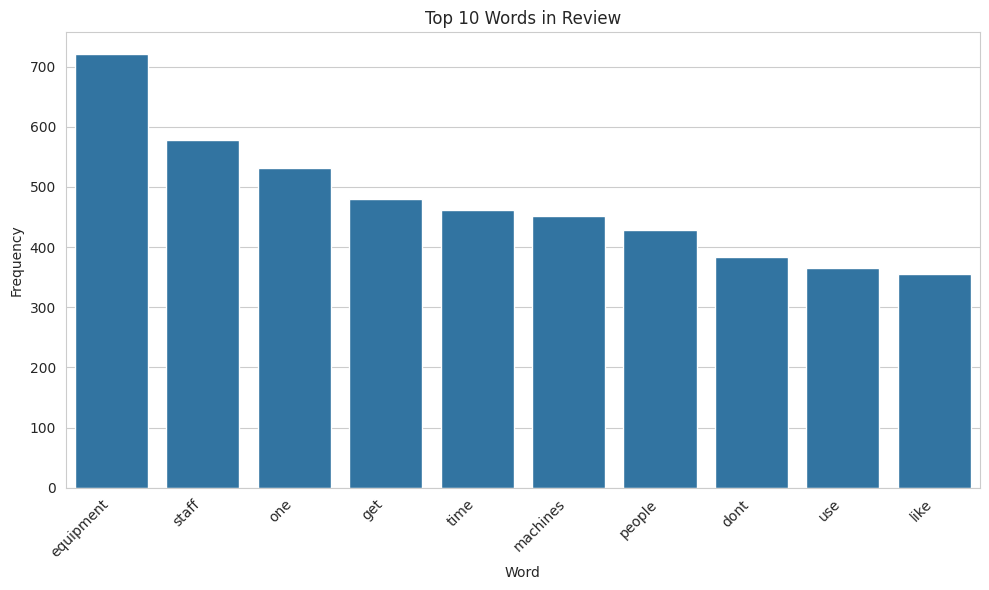

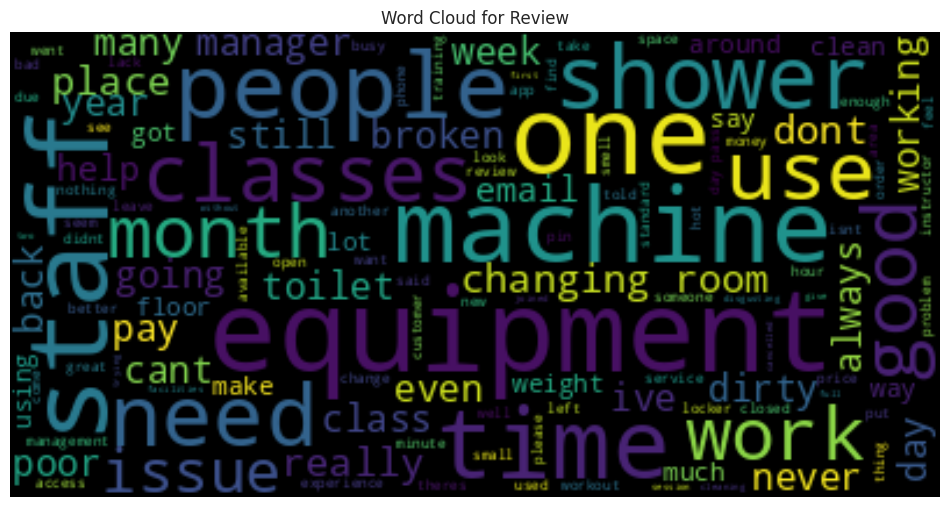

In [ ]:
# Apply to negative Trustpilot reviews.

word_cloud_display(negative_reviews_trustpilot, "Review", domain_stopwords, top_n=10)

In [ ]:
odd_reviews_trustpilot = negative_reviews_trustpilot[negative_reviews_trustpilot['Review'].str.contains('good', case=False)]

display(odd_reviews_trustpilot[['Stars', 'Review']])

,Stars,Review
100,2,smelly stuffy no proper ventilation. ive been ...
276,2,pure gym exeter. been a member at exeter for a...
308,1,ill pay for the jym workout when im reached th...
415,1,equipment is very good but unfriendly. equipme...
490,2,"could be a really good gym. great location, lo..."
...,...,...
16236,1,this is a very poorly managed gym . constantly...
16352,1,"pure gym dirty. pure gym bidston moss, i only ..."
16388,2,"good gym, equipment is great however the worke..."
16400,1,unfortunately this is a scam. they are making ...


The word “good” still appears in negative reviews because users often include qualified or comparative praise within otherwise critical feedback (e.g. “the only good thing…”, “used to be a good gym”). This reflects mixed sentiment, where positive elements are acknowledged but ultimately outweighed by negative experiences, so the review remains low-rated.

# Conducting Initial Topic Modelling:

Mapping fuzzy-matched locations into a shared naming convention, filtering both datasets to matched sites, combining them into one analysis table, and retaining only negative reviews for focused issue analysis.

In [ ]:
# Create mapping dictionaries from fuzzy matches.

# Map Trustpilot locations → Google locations.
tp_to_google = dict(zip(
    matches_df["trustpilot_location"],
    matches_df["google_location"]
))

# Reverse mapping (Google → Trustpilot).
google_to_tp = dict(zip(
    matches_df["google_location"],
    matches_df["trustpilot_location"]
))

# Filter both datasets using matched locations.

# Keep only Trustpilot rows with matched locations.

trustpilot_filtered = trustpilot_clean[
    trustpilot_clean["Location"].isin(tp_to_google.keys())
].copy()

# Keep only Google rows with matched locations.

google_filtered = google_clean[
    google_clean["Location"].isin(tp_to_google.values())
].copy()

# Standardise location naming across datasets.

# Map Trustpilot locations to the matched Google naming convention
trustpilot_filtered["Location_matched"] = trustpilot_filtered["Location"].map(tp_to_google)

# Google already uses the matched naming
google_filtered["Location_matched"] = google_filtered["Location"]

# Combine datasets (optional, for unified analysis).

combined_df_raw = pd.concat([
    trustpilot_filtered.assign(source="trustpilot"),
    google_filtered.assign(source="google")
])


# Sanity checks.

print("Trustpilot matched locations:", trustpilot_filtered["Location_matched"].nunique())
print("Google matched locations:", google_filtered["Location_matched"].nunique())

# Drop reviews with more than 2 stars.

combined_df_raw = combined_df_raw[combined_df_raw['Stars'] < 3]


print("Combined dataset shape:", combined_df_raw.shape)

display(combined_df_raw.head())

Trustpilot matched locations: 325
Google matched locations: 325
Combined dataset shape: (4088, 6)


,Location,Stars,Review,Date,Location_matched,source
2,sutton times square,1,"extremely busy, no fresh air.",2024-05-09 22:51:00,sutton times square,trustpilot
19,leeds city centre south,2,the mens changing rooms smell bad. they need a...,2024-05-09 18:09:00,leeds city centre south,trustpilot
48,dunfermline,1,no one was cleaning the equipment after. no on...,2024-05-09 09:16:00,dunfermline,trustpilot
51,bristol harbourside,1,not the best experience at 7am on a. not the b...,2024-05-09 08:03:00,bristol harbourside,trustpilot
55,birmingham snow hill plaza,2,instructor noshow on first day. i signed up fo...,2024-05-09 00:35:00,birmingham snow hill,trustpilot


In [ ]:
# Drop old location column.

combined_df = combined_df_raw.copy()
combined_df = combined_df.drop(columns=["Location"])
combined_df = combined_df.rename(columns={"Location_matched": "Location"})

# Reorder columns.

combined_df = combined_df[["Location", "Stars", "Review", "Date", "source"]]
combined_df = combined_df.rename(columns={"source": "Source"})

# Check.

display(combined_df)

,Location,Stars,Review,Date,Source
2,sutton times square,1,"extremely busy, no fresh air.",2024-05-09 22:51:00,trustpilot
19,leeds city centre south,2,the mens changing rooms smell bad. they need a...,2024-05-09 18:09:00,trustpilot
48,dunfermline,1,no one was cleaning the equipment after. no on...,2024-05-09 09:16:00,trustpilot
51,bristol harbourside,1,not the best experience at 7am on a. not the b...,2024-05-09 08:03:00,trustpilot
55,birmingham snow hill,2,instructor noshow on first day. i signed up fo...,2024-05-09 00:35:00,trustpilot
...,...,...,...,...,...
23229,london leytonstone,2,"equipment 710 theyre pretty good, over the yea...",2022-03-07 20:57:03,google
23233,london bermondsey,2,alright for the price. some members are a bit ...,2022-03-07 20:57:02,google
23234,bristol union gate,1,"disorganised, cramped, and untidy. the old fre...",2022-03-07 20:57:02,google
23235,bristol union gate,1,"music always too loud, especially when cycling...",2022-03-07 20:57:02,google


Confirming the final matched UK location set, providing the standardised geographic scope for combined review analysis across Google and Trustpilot.

In [ ]:
# New unique locations.

print("Unique locations:", combined_df["Location"].nunique(),'\n')

print(combined_df["Location"].unique())

Unique locations: 324 

['sutton times square' 'leeds city centre south' 'dunfermline'
 'bristol harbourside' 'birmingham snow hill' 'sunderland'
 'cambridge leisure park' 'london sydenham' 'southampton bitterne'
 'ipswich buttermarket' 'norwich aylsham road' 'london finchley'
 'london hoxton' 'aberdeen wellington' 'london stratford'
 'leicester st georges way' 'nottingham colwick' 'sevenoaks' 'eastbourne'
 'london greenwich movement' 'london hammersmith palais'
 'birmingham beaufort park' 'purley' 'london kingston'
 'exeter fore street' 'oldham' 'bedford heights'
 'peterborough brotherhood retail park' 'walsall crown wharf'
 'bradford idle' 'london beckton' 'edinburgh exchange crescent'
 'lisburn laganbank' 'manchester cheetham hill' 'romford' 'stowmarket'
 'london marylebone' 'london east sheen' 'livingston' 'glasgow robroyston'
 'aberdeen shiprow' 'sheffield millhouses' 'basildon' 'london bermondsey'
 'birmingham arcadian centre' 'west thurrock' 'london swiss cottage'
 'blackburn th

## BERTopic on Bad Reviews from Common Locations:

In [ ]:
# Inspect reviews.

print(combined_df['Review'])

2                            extremely busy, no fresh air.
19       the mens changing rooms smell bad. they need a...
48       no one was cleaning the equipment after. no on...
51       not the best experience at 7am on a. not the b...
55       instructor noshow on first day. i signed up fo...
                               ...                        
23229    equipment 710 theyre pretty good, over the yea...
23233    alright for the price. some members are a bit ...
23234    disorganised, cramped, and untidy. the old fre...
23235    music always too loud, especially when cycling...
23242    i used to love this gym, having been a member ...
Name: Review, Length: 4088, dtype: object


Preparing review text for BERT by lightly cleaning punctuation and formatting, then converting all negative reviews into a structured list for model input.

In [ ]:
# BERT preparation.

def prepare_bad_review_for_bert(text):
    # Handle null-like values.
    if text is None or str(text).lower() == "nan":
        return None

    text = str(text)

    # Remove basic punctuation only.
    text = re.sub(r'[.,!?;:()\-\"]+', ' ', text)

    # Removes standalone numbers only.
    text = re.sub(r'\b\d+\b', '', text)

    # Normalise whitespace.
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply to bad reviews dataframe.
combined_df["Review_BERT"] = combined_df["Review"].apply(prepare_bad_review_for_bert)

# Convert to list.
all_bad_reviews_list_clean = (
    combined_df["Review_BERT"]
    .dropna()
    .tolist()
)

# Check output.
print(all_bad_reviews_list_clean[0])
print("Number of cleaned bad reviews:", len(all_bad_reviews_list_clean))

extremely busy no fresh air
Number of cleaned bad reviews: 4088


Initialising a pre-trained BERT-based model for embedding and topic modelling of cleaned negative review text.

In [ ]:
# Pass bad review list to BERT.

model = BERTopic(verbose=True)
model.fit(all_bad_reviews_list_clean)
topic, probabilities = model.transform(all_bad_reviews_list_clean)

2026-04-26 15:36:26,143 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/128 [00:00<?, ?it/s]

2026-04-26 15:36:39,258 - BERTopic - Embedding - Completed ✓
2026-04-26 15:36:39,259 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-26 15:37:09,617 - BERTopic - Dimensionality - Completed ✓
2026-04-26 15:37:09,618 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-26 15:37:09,759 - BERTopic - Cluster - Completed ✓
2026-04-26 15:37:09,764 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 15:37:09,982 - BERTopic - Representation - Completed ✓


Batches:   0%|          | 0/128 [00:00<?, ?it/s]

2026-04-26 15:37:12,074 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-04-26 15:37:12,087 - BERTopic - Dimensionality - Completed ✓
2026-04-26 15:37:12,087 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-04-26 15:37:12,217 - BERTopic - Cluster - Completed ✓


In [ ]:
# Get the 10 most prominent topics.

model.get_topic_freq().head(10)

,Topic,Count
5,-1,1435
3,0,512
19,1,272
6,2,208
4,3,153
16,4,121
14,5,91
13,6,85
22,7,85
1,8,81


The model identifies a large outlier cluster (Topic -1) containing 1,435 reviews, indicating many observations do not fit clearly into defined themes, alongside a smaller number of coherent topics with declining sizes, suggesting a few dominant patterns and several more niche issues.

In [ ]:
# Topic 1.

model.get_topic(0)

[('my', np.float64(0.02564847109045464)),
 ('to', np.float64(0.024493760257052022)),
 ('me', np.float64(0.01952592443265767)),
 ('was', np.float64(0.01795486020335462)),
 ('for', np.float64(0.017747902568074986)),
 ('membership', np.float64(0.017506801765043146)),
 ('pass', np.float64(0.017062642020890705)),
 ('pin', np.float64(0.01702162931875432)),
 ('the', np.float64(0.016782807328030343)),
 ('code', np.float64(0.016357556122787394))]

Topic 1 appears to relate to membership access and entry issues, with terms such as “membership”, “pin”, and “code” indicating problems around login, access, or account setup, although the signal is diluted by generic words.

In [ ]:
# Topic 2.

model.get_topic(1)

[('showers', np.float64(0.05863700642276665)),
 ('cold', np.float64(0.038991704865601884)),
 ('shower', np.float64(0.036790504269652864)),
 ('water', np.float64(0.02760867990009967)),
 ('the', np.float64(0.021261724169784217)),
 ('hot', np.float64(0.020644874465040677)),
 ('are', np.float64(0.01868425297988812)),
 ('and', np.float64(0.018006812041330464)),
 ('to', np.float64(0.01696077012409076)),
 ('is', np.float64(0.015302867646428013))]

Topic 2 shows a clearer theme around shower and facility conditions, with strong, high-weighted terms like “showers”, “cold”, and “water”, highlighting consistent issues with temperature and cleanliness despite some residual low-signal words.

In [ ]:
# Visualise model topics.

model.visualize_topics()

The intertopic distance map visualises how distinct the identified topics are from one another based on their semantic similarity. Each circle represents a topic, where size reflects the number of reviews in that topic and distance between circles indicates how different the topics are—closer topics are more similar in content, while those further apart represent more distinct themes.

In [ ]:
# Visualise topics as bar chart.

model.visualize_barchart()

The topic mix shows a combination of high-signal and low-signal clusters.

* High-signal topics include clear, actionable themes such as showers (cold water issues), air conditioning/heat, parking availability, music/noise levels, and access/hours (e.g. 24/7, closures). These are well-defined and operationally relevant.
* Moderate signal topics include areas like classes, which are identifiable but still contain some generic filler terms.
* Low-signal topics (e.g. Topics 0 and 6) are dominated by common words like “my”, “to”, “she”, “me”, indicating weak thematic coherence and limited interpretability.

Overall, the model captures several strong operational pain points, but a subset of topics remains noisy due to insufficient filtering of generic language.

In [ ]:
# Visualise topics with a heatmap.

model.visualize_heatmap()

The similarity matrix shows the degree of overlap between topics, with darker cells indicating higher similarity. The strong diagonal reflects each topic’s perfect similarity with itself, while off-diagonal patterns highlight clusters of related themes, such as facilities (toilets, cleaning, smells), equipment (machines, repairs), and overcrowding/access issues.

Notably, several topics exhibit moderate-to-high similarity with others, suggesting theme redundancy and overlap, while low-signal topics (e.g. generic word clusters) show weaker and more diffuse relationships.

In [ ]:
# Reduce BERTopic output to 10 topics and visualise topic hierarchy / dendrogram.

# Reduce topics to 10 for interpretability.
model = model.reduce_topics(
    all_bad_reviews_list_clean,
    nr_topics=10
)

# Check reduced topic structure.
topic_info_10 = model.get_topic_info()
display(topic_info_10)

# Create hierarchical topic structure.
hierarchical_topics = model.hierarchical_topics(
    all_bad_reviews_list_clean
)

# Visualise dendrogram / hierarchy.
fig = model.visualize_hierarchy(
    hierarchical_topics=hierarchical_topics
)

# Increase figure size

fig.update_layout(
    width=1200,   # increase width
    height=800    # increase height
)

fig.show()

2026-04-26 15:50:14,494 - BERTopic - Topic reduction - Reducing number of topics
2026-04-26 15:50:14,503 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 15:50:14,703 - BERTopic - Representation - Completed ✓
2026-04-26 15:50:14,705 - BERTopic - Topic reduction - Reduced number of topics from 42 to 10


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1435,-1_the_and_to_of,"[the, and, to, of, gym, is, in, for, it, are]",[shocking gym 20 people in there and it feels ...
1,0,1299,0_the_to_and_gym,"[the, to, and, gym, is, of, in, for, this, are]",[not enough kit very basic gym worst puregym i...
2,1,885,1_to_the_and_my,"[to, the, and, my, gym, for, was, it, not, no]",[been told to stop my exercise i was using the...
3,2,106,2_toilets_toilet_the_and,"[toilets, toilet, the, and, no, of, changing, ...",[expected better big letdown by puregym stop t...
4,3,88,3_too_busy_kids_crowded,"[too, busy, kids, crowded, people, many, overc...","[too busy, too busy, too busy]"
5,4,69,4_locker_lockers_the_and,"[locker, lockers, the, and, my, in, to, not, s...",[vandalism to lockers careless staff on enteri...
6,5,66,5_rude_staff_manager_and,"[rude, staff, manager, and, unprofessional, ve...",[rude staff faulty equipment is not fixed for ...
7,6,50,6_equipment_of_out_for,"[equipment, of, out, for, and, they, broken, i...",[most of the equipment is old and dated very w...
8,7,46,7_wifi_signal_no_the,"[wifi, signal, no, the, is, to, and, of, in, t...",[sort the wifi the wifi in the exchange quays ...
9,8,44,8_never_go_been_there,"[never, go, been, there, not, didnt, know, per...","[never been, never been, i have never been there]"


100%|██████████| 8/8 [00:00<00:00, 236.47it/s]


Reducing the model to 10 topics improves interpretability, but a large proportion of reviews remain in the outlier cluster (Topic -1), indicating persistent noise and weak clustering. The remaining topics capture clearer operational themes - such as overcrowding, toilets, lockers, staff behaviour, equipment issues, and WiFi - while the hierarchical clustering shows how these group into broader categories (e.g. facilities vs service vs access), alongside low-signal clusters dominated by generic language.

Initial BERTopic outputs included topics dominated by stopwords, which is expected due to the use of bag-of-words representations for topic extraction. This was addressed by introducing a custom stopword list in the vectorizer, improving topic interpretability.

In [ ]:
# Standard English stopwords.
stop_words = set(stopwords.words("english"))

# Combine stopwords.
all_stopwords = stop_words.union(domain_stopwords)

# Vectorizer for BERTopic topic representation.
vectorizer_model = CountVectorizer(
    stop_words=list(all_stopwords),
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,  # Increased max_df to include more frequent words
    max_features=10000 # Increased max_features to capture a broader vocabulary
)

In [ ]:
# Use with BERTopic.
refined_model = BERTopic(
    vectorizer_model=vectorizer_model,
    verbose=True
)

topics, probs = refined_model.fit_transform(all_bad_reviews_list_clean)

2026-04-26 15:53:17,896 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/128 [00:00<?, ?it/s]

2026-04-26 15:53:25,467 - BERTopic - Embedding - Completed ✓
2026-04-26 15:53:25,468 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-26 15:53:47,617 - BERTopic - Dimensionality - Completed ✓
2026-04-26 15:53:47,619 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-26 15:53:47,760 - BERTopic - Cluster - Completed ✓
2026-04-26 15:53:47,764 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 15:53:48,353 - BERTopic - Representation - Completed ✓


In [ ]:
# Get the 10 most prominent topics.

refined_model.get_topic_freq().head(10)

,Topic,Count
2,-1,1470
3,0,503
5,1,210
4,2,154
1,3,144
16,4,122
7,5,95
14,6,91
18,7,85
23,8,85


The adjusted vectoriser has refined topic composition slightly but not materially changed the overall structure.

* The outlier cluster (Topic -1) increases marginally (1435 → 1470), suggesting that stricter stopword filtering has pushed more ambiguous reviews out of defined topics rather than improving assignment.
* The largest core topic remains broadly stable (512 → 503), indicating that dominant themes are robust to stopword adjustments.
* Mid-sized topics show minor redistribution of counts, reflecting some improvement in separating themes, but no major reorganisation of topic structure.
* Overall, while the vectoriser reduces noise in topic representation (i.e. clearer keywords), it does not significantly improve clustering performance, as evidenced by the persistent and slightly larger outlier group.

In short, the change improves interpretability of topics, but not model fit or topic separation.

In [ ]:
# Topic 1.

refined_model.get_topic(0)

[('pin', np.float64(0.02955676642759826)),
 ('pass', np.float64(0.0291318691654303)),
 ('day', np.float64(0.0254653359671576)),
 ('access', np.float64(0.02532093342571619)),
 ('day pass', np.float64(0.024680119323178814)),
 ('get', np.float64(0.022138358992144752)),
 ('didnt', np.float64(0.021384691544623698)),
 ('email', np.float64(0.020961276252975943)),
 ('help', np.float64(0.019477106745227745)),
 ('joining', np.float64(0.018376469893879848))]

In [ ]:
# Topic 2.

refined_model.get_topic(1)

[('air', np.float64(0.06668774759364689)),
 ('conditioning', np.float64(0.038440332197214565)),
 ('air conditioning', np.float64(0.038440332197214565)),
 ('hot', np.float64(0.03603918870522569)),
 ('aircon', np.float64(0.03211653470654584)),
 ('ac', np.float64(0.031289544100209225)),
 ('air con', np.float64(0.030325929849893133)),
 ('con', np.float64(0.03004267243919237)),
 ('summer', np.float64(0.02355584050480481)),
 ('temperature', np.float64(0.02028214965950752))]

The refined topics show a clear improvement in signal and specificity.

* Topic 1 has shifted from generic language to a well-defined theme around access and onboarding issues, including PIN codes, day passes, and entry problems.
* Topic 2 is now highly coherent, clearly capturing air conditioning and temperature issues, with consistent terminology (e.g. “air conditioning”, “aircon”, “AC”).

Overall, the refinement reduces noise and produces more actionable, operationally relevant topics.

In [ ]:
# Visualise model topics.

refined_model.visualize_topics()

In [ ]:
# Visualise topics as bar chart.

refined_model.visualize_barchart()

The refined version shows a clear step-change in topic quality and interpretability compared to the previous output.

* Stronger signal, less noise: Previously, several topics were dominated by generic words (e.g. “my”, “to”, “the”), whereas the refined model removes this noise and produces clean, domain-relevant terms.
* More distinct, actionable themes: Topics are now clearly separated into operational issues such as access (PIN/pass), air conditioning, classes/instructors, toilets/cleanliness, parking, staff behaviour, noise/music, and broken equipment. These are far more usable for decision-making.
* Reduced topic overlap: Earlier topics showed conceptual overlap (e.g. facilities mixed with generic terms), whereas the refined model isolates specific pain points, improving thematic clarity.
* Improved consistency within topics: Each topic now contains coherent, tightly related keywords, rather than a mix of high- and low-signal terms.

Overall, the refinement materially improves topic coherence, separation, and business relevance, even if the underlying distribution (e.g. outliers) has not significantly changed.

In [ ]:
# Reduce BERTopic output to 10 topics and visualise topic hierarchy / dendrogram.

# Reduce topics to 10 for interpretability.
refined_model = refined_model.reduce_topics(
    all_bad_reviews_list_clean,
    nr_topics=10
)

# Check reduced topic structure.
topic_info_10 = refined_model.get_topic_info()
display(topic_info_10)

# Create hierarchical topic structure.
hierarchical_topics = refined_model.hierarchical_topics(
    all_bad_reviews_list_clean
)

# Visualise dendrogram / hierarchy.
fig = refined_model.visualize_hierarchy(
    hierarchical_topics=hierarchical_topics
)

# Increase figure size

fig.update_layout(
    width=1200,   # increase width
    height=800    # increase height
)

fig.show()

2026-04-26 15:56:39,328 - BERTopic - Topic reduction - Reducing number of topics
2026-04-26 15:56:39,336 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 15:56:39,891 - BERTopic - Representation - Completed ✓
2026-04-26 15:56:39,893 - BERTopic - Topic reduction - Reduced number of topics from 45 to 10


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1470,-1_equipment_machines_one_staff,"[equipment, machines, one, staff, people, time...",[ive been at this puregym for just over a year...
1,0,1512,0_get_staff_class_classes,"[get, staff, class, classes, parking, one, day...",[been going here for a couple months now two t...
2,1,477,1_showers_dirty_cleaning_shower,"[showers, dirty, cleaning, shower, toilets, co...",[been going here since 2021 usually late in th...
3,2,256,2_air_hot_conditioning_air conditioning,"[air, hot, conditioning, air conditioning, ac,...",[sweltering the gym is far too hot to work out...
4,3,142,3_water_machines_broken_machine,"[water, machines, broken, machine, order, fix,...",[been going to this gym for few years now and ...
5,4,76,4_busy_kids_crowded_people,"[busy, kids, crowded, people, overcrowded, ful...",[full of kids and with attuite and full of kid...
6,5,61,5_rude_staff_manager_management,"[rude, staff, manager, management, managers, p...","[rude staff, staff was very rude and very staf..."
7,6,46,6_never_go_didnt_know,"[never, go, didnt, know, rubbish, go back, don...","[i have never been there, never been, never been]"
8,7,37,7_equipment_lot equipment_equipment needs_equi...,"[equipment, lot equipment, equipment needs, eq...",[small and not a lot of equipment for the pric...
9,8,11,8_booked_first_go_person,"[booked, first, go, person, time, one, class, ...",[first impressions were not good booked an ind...


100%|██████████| 8/8 [00:00<00:00, 287.14it/s]


Cluster 0 – General gym experience (low signal / mixed issues)
Comprised of broad terms such as equipment, machines, staff, people, time, place, this cluster reflects a diffuse mix of general complaints, combining equipment, crowding, and staff issues without a single dominant theme.

Cluster 1 – Staff behaviour and member experience
With keywords like staff, class, people, parking, equipment, this cluster captures negative interactions with staff and poor gym culture, including lack of enforcement and member behaviour issues.

Cluster 2 – Cleanliness and hygiene (showers & changing rooms)
Driven by showers, dirty, cleaning, toilets, smell, water, this cluster clearly represents poor hygiene standards, particularly in changing rooms and shower facilities.

Cluster 3 – Air conditioning and temperature issues
Keywords such as air, hot, conditioning, AC indicate a focused theme around poor ventilation and overheating, highlighting discomfort during workouts.

Cluster 4 – Broken equipment and maintenance delays
With machines, broken, fix, weeks, months, this cluster reflects persistent equipment failures and slow repair times, indicating weak maintenance processes.

Cluster 5 – Overcrowding and disruptive behaviour (youth-heavy usage)
Terms like busy, crowded, kids, people, phones point to overcrowding and poor member etiquette, particularly driven by large groups and misuse of equipment.

Cluster 6 – Rude staff and poor management
Keywords rude, staff, manager, management highlight a clear interpersonal issue, focused on unprofessional or hostile staff behaviour.

Cluster 7 – Irrelevant / low-information reviews
Dominated by never, didn’t, know, this cluster captures non-informative or irrelevant reviews, offering minimal actionable insight.

Cluster 8 – Poor equipment quality and insufficient provision
With equipment, needs updating, poor, old, this cluster reflects outdated or insufficient equipment, distinct from outright breakages (Cluster 4).

Cluster 9 – Onboarding and class experience failures
Keywords such as booked, class, first, experience indicate poor first impressions, including missed inductions, no-shows, and lack of guidance in classes.

# Performing further Data Investigation (Location-based):

Identifying the top 20 locations with the highest volume of negative reviews across Google and Trustpilot to compare geographic patterns and consistency between data sources.

In [ ]:
# Drop reviews with more than 2 stars in original datasets.

negative_google = google_clean[google_clean['Stars'] < 3]
negative_trustpilot = trustpilot_clean[trustpilot_clean['Stars'] < 3]

# Sort for the top 20 location in each dataset.

top_20_google = negative_google['Location'].value_counts().head(20)
top_20_trustpilot = negative_trustpilot['Location'].value_counts().head(20)

print(top_20_google, '\n')
print(top_20_trustpilot)

Location
london stratford            59
london woolwich             26
london canary wharf         26
london enfield              25
london swiss cottage        23
london palmers green        22
birmingham city centre      21
new barnet                  20
london leytonstone          20
bradford thornbury          18
wakefield                   18
peterborough serpentine     18
london hoxton               18
walsall crown wharf         18
london hayes                17
london seven sisters        17
manchester exchange quay    17
sutton times square         16
london bermondsey           16
nottingham colwick          16
Name: count, dtype: int64 

Location
leicester walnut street      50
london enfield               23
london stratford             22
burnham                      20
london bermondsey            18
london ilford                18
london seven sisters         16
york                         16
london hayes                 16
maidenhead                   16
london finchle

The results show a strong overlap in high-negative-review locations across both datasets, particularly in major urban areas such as London (Stratford, Enfield, Bermondsey, Hayes, Seven Sisters, Swiss Cottage) and regional hubs like Bradford Thornbury and New Barnet.

While there are some differences in ranking and additional locations unique to each source (e.g. Leicester Walnut Street in Trustpilot), the overall pattern is consistent, suggesting that negative sentiment is concentrated in the same key sites across both platforms, reinforcing the reliability of the findings.

In [ ]:
# Review counts dataframe.

review_counts = (
    combined_df
    .groupby(["Location", "Source"])
    .size()
    .unstack(fill_value=0)
)

review_counts = review_counts.rename(columns={
    "trustpilot": "Trustpilot_Reviews",
    "google": "Google_Reviews"
})

review_counts["Total_Reviews"] = (
    review_counts["Trustpilot_Reviews"] +
    review_counts["Google_Reviews"]
)

review_counts = review_counts.sort_values(
    by="Total_Reviews",
    ascending=False
)

review_counts = review_counts.reset_index()
display(review_counts.head(20))

Source,Location,Google_Reviews,Trustpilot_Reviews,Total_Reviews
0,london stratford,59,22,81
1,leicester walnut street,11,50,61
2,london enfield,25,23,48
3,london swiss cottage,23,15,38
4,birmingham city centre,21,14,35
5,london bermondsey,16,18,34
6,new barnet,20,14,34
7,london hayes,17,16,33
8,london seven sisters,17,16,33
9,bradford thornbury,18,14,32


Now, for the Top 30 locations:

In [ ]:
# Top 30.

top_30 = review_counts.head(30)
display(top_30)

Source,Location,Google_Reviews,Trustpilot_Reviews,Total_Reviews
0,london stratford,59,22,81
1,leicester walnut street,11,50,61
2,london enfield,25,23,48
3,london swiss cottage,23,15,38
4,birmingham city centre,21,14,35
5,london bermondsey,16,18,34
6,new barnet,20,14,34
7,london hayes,17,16,33
8,london seven sisters,17,16,33
9,bradford thornbury,18,14,32


Geocoding the top locations to latitude and longitude coordinates and visualising the distribution of negative reviews on a UK map based on review volume.

In [ ]:
# Set up geocoder
geolocator = Nominatim(user_agent="review_map")

# Function to geocode one location
def get_lat_lon(location):
    try:
        loc = geolocator.geocode(f"{location}, UK")
        time.sleep(1)  # respect Nominatim rate limits

        if loc:
            return loc.latitude, loc.longitude
        else:
            return None, None

    except:
        return None, None

# Apply geocoding to top 30 only
top_30["lat"], top_30["lon"] = zip(
    *top_30["Location"].apply(get_lat_lon)
)

# Drop any locations that could not be geocoded
top_30_clean = top_30.dropna(subset=["lat", "lon"]).copy()

# Plot map
fig = px.scatter_mapbox(
    top_30_clean,
    lat="lat",
    lon="lon",
    size="Total_Reviews",
    color="Total_Reviews",
    hover_name="Location",
    hover_data={
        "Google_Reviews": True,
        "Trustpilot_Reviews": True,
        "Total_Reviews": True,
        "lat": False,
        "lon": False
    },
    color_continuous_scale="Reds",
    size_max=40,
    zoom=5,
    height=700
)

fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_center={"lat": 54, "lon": -2},
    mapbox_zoom=5,
    margin={"r": 0, "t": 40, "l": 0, "b": 0}
)

fig.show()

The map highlights a clear geographic concentration of negative review hotspots, with the highest density in London and the South East, where multiple large clusters indicate consistently high volumes of complaints across several locations.

Secondary hotspots appear in major urban centres such as Birmingham, Manchester, and Leeds, suggesting that negative sentiment is primarily concentrated in high-traffic, densely populated areas. Overall, the distribution indicates that scale, footfall, and capacity pressures are likely key drivers of dissatisfaction.

In [ ]:
# Filter top 30 from combined dataframe.

top_30_list = top_30['Location'].tolist()

top_30_df = combined_df[combined_df['Location'].isin(top_30_list)]

## Topic Modelling for Top 30 Locations:

Combining Google and Trustpilot reviews for the top 30 locations and applying BERTopic to identify location-specific themes in negative feedback.

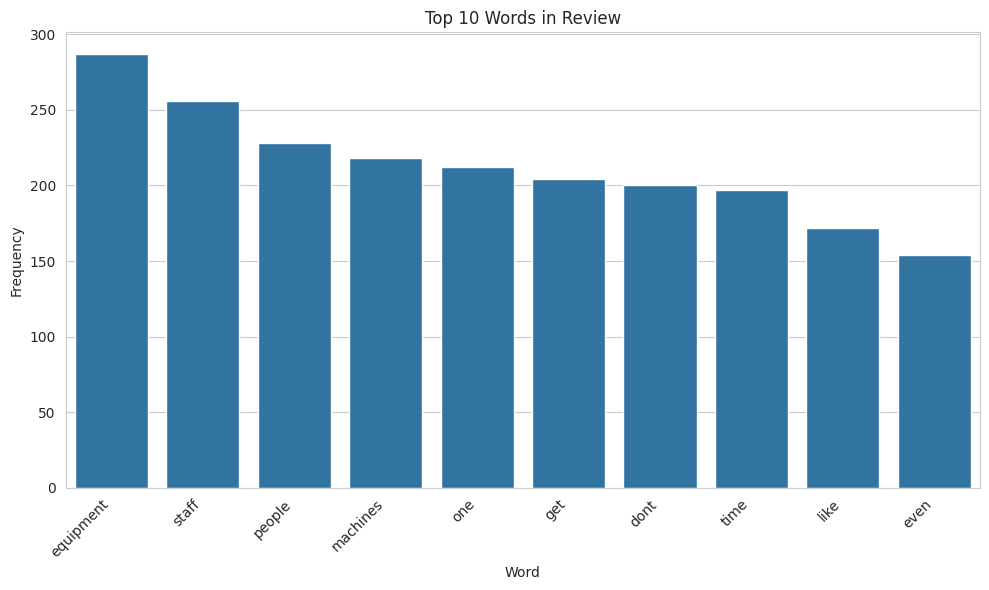

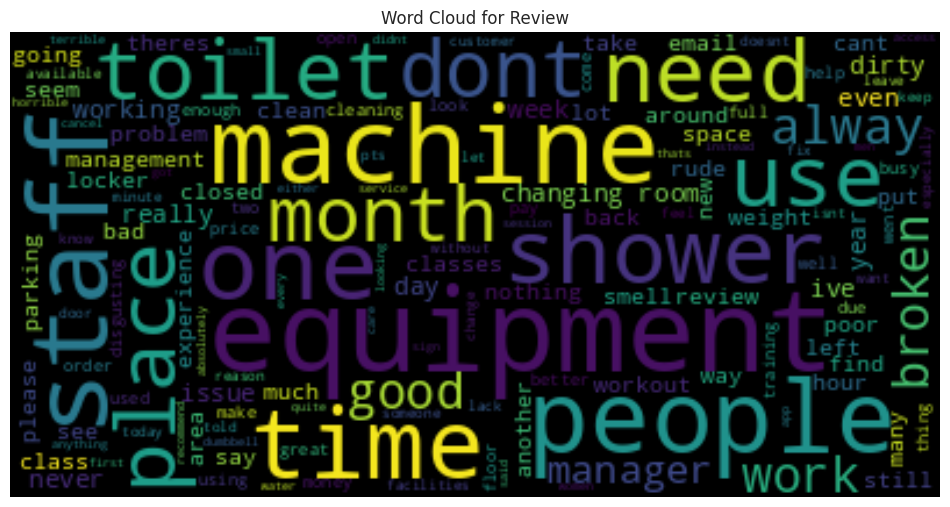

In [ ]:
# Redo word cloud and frequency distribution with top 30.

word_cloud_display(top_30_df, "Review", domain_stopwords, top_n=10)

The results are broadly consistent with the first run, with core themes such as equipment, staff, machines, and cleanliness (e.g. toilets/showers) still dominating.

However, the focus on the top 30 locations introduces a more concentrated and operational signal, with clearer emphasis on specific pain points such as broken machines, poor hygiene (toilets, showers, smell), and access/usage issues. Generic filler terms still appear but are relatively less dominant.

Compared to the initial run, this subset provides more targeted insights, highlighting that the most problematic locations are driven by facility maintenance, overcrowding/usage constraints, and cleanliness issues, rather than broad sentiment alone.

In [ ]:
# Apply to top 30 bad reviews dataframe.

top_30_df["Review_BERT"] = top_30_df["Review"].apply(prepare_bad_review_for_bert)

# Convert to list.
top_30_reviews_list_clean = (
    top_30_df["Review_BERT"]
    .dropna()
    .tolist()
)

# Check output.
print(top_30_reviews_list_clean[0])
print("Number of cleaned bad reviews:", len(top_30_reviews_list_clean))

extremely busy no fresh air
Number of cleaned bad reviews: 948


The model will likely produce only one dominant, noisy topic because the input corpus is too small and homogeneous. With limited reviews (top 30 subset), BERTopic has insufficient variation to form distinct clusters, causing most documents to collapse into a single topic. Additionally, high-frequency, low-information words dominate the vectorizer stage, reducing topic separability.

To increase the number of topics found by BERTopic, we can adjust the min_cluster_size parameter of the underlying HDBSCAN clustering algorithm. A smaller min_cluster_size allows for more granular clusters. I will set it to 5, which should help identify more distinct topics. Then, we will re-run the BERTopic model and check the new topic frequencies.

In [ ]:
from hdbscan import HDBSCAN

# Define a custom HDBSCAN model with a smaller min_cluster_size
hdbscan_model = HDBSCAN(min_cluster_size=5, metric='euclidean', cluster_selection_epsilon=0.5, prediction_data=True)

# Re-initialize BERTopic with the custom HDBSCAN model and the existing vectorizer
increased_topics_model = BERTopic(
    vectorizer_model=vectorizer_model,
    hdbscan_model=hdbscan_model,
    verbose=True
)

# Fit and transform the reviews
topics_increased, probs_increased = increased_topics_model.fit_transform(top_30_reviews_list_clean)

2026-04-26 16:31:22,015 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

2026-04-26 16:31:28,203 - BERTopic - Embedding - Completed ✓
2026-04-26 16:31:28,204 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-26 16:31:29,687 - BERTopic - Dimensionality - Completed ✓
2026-04-26 16:31:29,688 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-26 16:31:29,720 - BERTopic - Cluster - Completed ✓
2026-04-26 16:31:29,723 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 16:31:29,842 - BERTopic - Representation - Completed ✓


Now that we've adjusted the `min_cluster_size`, let's try visualizing the topics again to see if more distinct clusters have been identified.

In [ ]:
# Get the 10 most prominent topics with the increased topic count
increased_topics_model.get_topic_freq().head(10)

,Topic,Count
0,0,839
4,1,37
3,-1,29
1,2,20
5,3,13
2,4,10


Moving from the full set of negative reviews to the top 30 locations significantly reduces sample size, resulting in smaller, less stable topics and a higher proportion of outliers. This indicates weaker clustering and less clearly defined themes, as the model has less data to form coherent topic structures.

In [ ]:
# Visualize model topics with the increased topic count.

increased_topics_model.visualize_topics()

In [ ]:
# Visualise topics as bar chart with the increased topic count.

increased_topics_model.visualize_barchart()

The newer bar plots exhibit low signal and weak thematic clarity, with topics dominated by generic terms such as “people”, “time”, “get”, and “even”. This limits interpretability, as the model is not capturing distinct operational issues but rather diffuse, non-specific language - likely driven by the smaller sample size and reduced data context.

In [ ]:
# Reduce BERTopic output to 10 topics and visualise topic hierarchy / dendrogram.
# Reduce topics to 10 for interpretability.
increased_topics_model = increased_topics_model.reduce_topics(
    top_30_reviews_list_clean,
    nr_topics=10
)

# Check reduced topic structure.
topic_info_10_increased = increased_topics_model.get_topic_info()
display(topic_info_10_increased)

# Create hierarchical topic structure.
hierarchical_topics_increased = increased_topics_model.hierarchical_topics(
    top_30_reviews_list_clean
)

# Visualise dendrogram / hierarchy.
fig_increased = increased_topics_model.visualize_hierarchy(
    hierarchical_topics=hierarchical_topics_increased
)

# Increase figure size

fig_increased.update_layout(
    width=1200,   # increase width
    height=800    # increase height
)

fig_increased.show()

2026-04-26 16:32:37,406 - BERTopic - Topic reduction - Reducing number of topics
2026-04-26 16:32:37,406 - BERTopic - Topic reduction - Number of topics (10) is equal or higher than the clustered topics(6).
2026-04-26 16:32:37,407 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 16:32:37,550 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,29,-1_pay_month_one_even,"[pay, month, one, even, people, cant, also, li...",[someone vandalized the gyms fire system durin...
1,0,839,0_staff_people_one_get,"[staff, people, one, get, time, like, also, wo...",[no matter what time it is this gym is always ...
2,1,37,1_ive_times_staff_time,"[ive, times, staff, time, get, people, pay, we...",[everything well sideway from the very beginni...
3,2,20,2_even_people_get_available,"[even, people, get, available, take, ive, time...",[i wasnt let in booked class i had booked pila...
4,3,13,3_pay_weeks_wait_month,"[pay, weeks, wait, month, time, ive, also, giv...",[its a small gym usually overcrowded at any ti...
5,4,10,4_go_absolutely__,"[go, absolutely, , , , , , , , ]","[absolutely rubbish, not great really disappoi..."


100%|██████████| 4/4 [00:00<00:00, 307.29it/s]


# Conducting emotion analysis:

Loading a pre-trained BERT emotion classification model from Hugging Face and configuring it to run efficiently using GPU acceleration where available.

In [ ]:
# Import BERT emotion model and run batched inference with GPU support.

# Check GPU availability.
device = 0 if torch.cuda.is_available() else -1

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Load emotion classifier.

classifier = pipeline(
    "text-classification",
    model="bhadresh-savani/bert-base-uncased-emotion",
    top_k=1,          # return only the top emotion
    device=device
)

GPU available: True
GPU: NVIDIA L4


config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bhadresh-savani/bert-base-uncased-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Testing the model on a sample sentence to demonstrate its emotion classification outputs and verify correct setup.

In [ ]:
# Trial with a test prompt.

test_prompt = "I love to hate this gym"

emotion_labels = classifier(test_prompt)

print(emotion_labels)

[[{'label': 'anger', 'score': 0.9947856068611145}]]


Applying the BERT model in batches to efficiently classify each review and extract the dominant emotion label.

In [ ]:
# Function to run classifier in batches and return top emotion.

def get_top_emotions_batched(df, text_col="Review", batch_size=64):
    texts = df[text_col].fillna("").astype(str).str[:256].tolist()
    results = classifier(
        texts,
        batch_size=batch_size,
        truncation=True
    )

    top_emotions = [
        result[0]["label"] if text.strip() != "" else None
        for text, result in zip(texts, results)
    ]

    return top_emotions

In [ ]:
# Apply ONLY to negative reviews.

negative_reviews_google = negative_reviews_google.copy()
negative_reviews_trustpilot = negative_reviews_trustpilot.copy()

negative_reviews_google["Top_Emotion"] = get_top_emotions_batched(
    negative_reviews_google,
    text_col="Review",
    batch_size=64
)

negative_reviews_trustpilot["Top_Emotion"] = get_top_emotions_batched(
    negative_reviews_trustpilot,
    text_col="Review",
    batch_size=64
)

In [ ]:
# Inspect outputs.

display(negative_reviews_google[["Review", "Top_Emotion"]].head())

,Review,Top_Emotion
1,too many students from two local colleges go h...,anger
4,"current member gym is quite dirty, more often ...",sadness
7,this gym is way too hot to even workout in. th...,anger
19,no access for wc . empty and no assistance to ...,sadness
29,after being at this gym for over a year im fin...,love


In [ ]:
# Inspect outputs.

display(negative_reviews_trustpilot[["Review", "Top_Emotion"]].head())

,Review,Top_Emotion
2,"extremely busy, no fresh air.",joy
19,the mens changing rooms smell bad. they need a...,joy
48,no one was cleaning the equipment after. no on...,fear
51,not the best experience at 7am on a. not the b...,anger
55,instructor noshow on first day. i signed up fo...,joy


The emotion classifications are directionally useful and capture clear cases (e.g. anger, sadness), but there are notable inaccuracies where reviews contain mixed or ambiguous sentiment. In several instances, strongly negative feedback is misclassified as “joy” or “love”, reflecting the model’s difficulty in handling nuanced language, sarcasm, or conflicting statements within the same review.

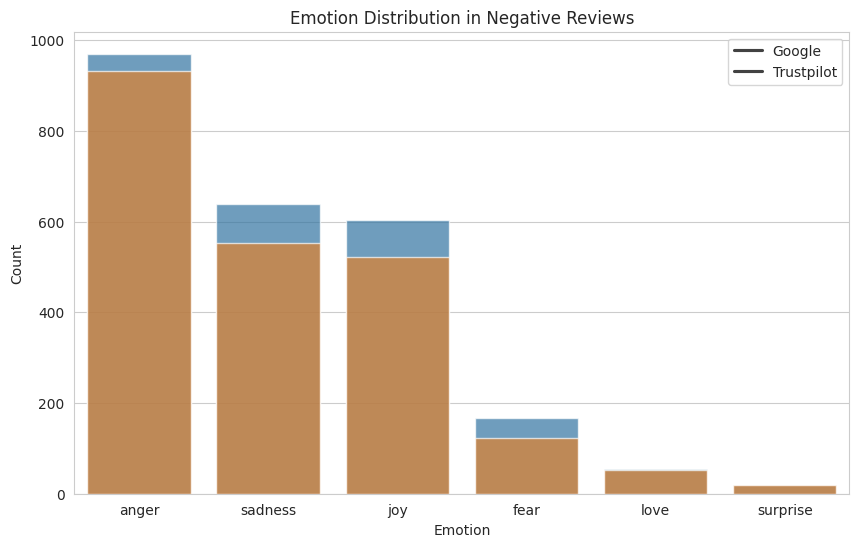

In [ ]:
# Calculate emotion counts.

emotion_counts_google = negative_reviews_google["Top_Emotion"].value_counts()
emotion_counts_trustpilot = negative_reviews_trustpilot["Top_Emotion"].value_counts()

# Visualise Barplots.

plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_counts_google.index, y=emotion_counts_google.values, alpha=0.7)
sns.barplot(x=emotion_counts_trustpilot.index, y=emotion_counts_trustpilot.values, alpha=0.7)
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.title("Emotion Distribution in Negative Reviews")
plt.legend(["Google", "Trustpilot"])
plt.show()

The distribution is heavily skewed towards anger, which is the dominant emotion across both datasets, followed by sadness and then joy. Lower-frequency emotions such as fear, love, and surprise appear only marginally. The similar shape across Google and Trustpilot suggests consistent emotional patterns, although the presence of “joy” in negative reviews highlights some classification noise.

In [ ]:
# Filter dataframes for anger as emotion.

anger_google = negative_reviews_google[negative_reviews_google["Top_Emotion"] == "anger"]
anger_trustpilot = negative_reviews_trustpilot[negative_reviews_trustpilot["Top_Emotion"] == "anger"]

print(f"Angry Google Reviews: {len(anger_google)}")
print(f"Angry TrustPilot Reviews: {len(anger_trustpilot)}")

Angry Google Reviews: 970
Angry TrustPilot Reviews: 932


In [ ]:
# Concatenate both angry review datasets.

all_angry_reviews = pd.concat([
    anger_google.assign(source="google"),
    anger_trustpilot.assign(source="trustpilot")
])

all_angry_reviews = all_angry_reviews.rename(columns={"Top_Emotion": "Emotion"})
all_angry_reviews = all_angry_reviews.rename(columns={"source": "Source"})

display(all_angry_reviews.head(5))

,Location,Stars,Review,Date,Emotion,Source
1,cambridge leisure park,1,too many students from two local colleges go h...,2024-05-09 22:48:39,anger,google
7,new barnet,2,this gym is way too hot to even workout in. th...,2024-05-09 20:16:04,anger,google
57,london oval,1,the gym is huge but where is all the equipment...,2024-05-08 22:31:31,anger,google
65,new barnet,1,airconditioning doesnt work,2024-05-08 20:20:02,anger,google
67,rochdale,1,"my friend is new to the gym, she had just join...",2024-05-08 19:59:48,anger,google


In [ ]:
# Apply to top 30 bad reviews dataframe.

all_angry_reviews["Review_BERT"] = all_angry_reviews["Review"].apply(prepare_bad_review_for_bert)

# Convert to list.
all_angry_reviews_list = (
    all_angry_reviews["Review_BERT"]
    .dropna()
    .tolist()
)

# Check output.
print(all_angry_reviews_list[0])
print("Number of cleaned bad reviews:", len(all_angry_reviews_list))

too many students from two local colleges go her leave rubbish in changing rooms and sit there like there in a canteen been going here for 5 years will cancel my membership and go to gym group this gym is disgusting students hanging around machines and messing around like there at school too over crowded and their ceo supports the genocide of civilians by israel disgusting people
Number of cleaned bad reviews: 1902


## Applying BERT on reviews classified as angry:

Applying BERTopic to anger-labelled reviews to identify the main themes and recurring issues driving angry customer feedback.

In [ ]:
# Use with BERTopic.
angry_model = BERTopic(
    vectorizer_model=vectorizer_model,
    verbose=True
)

topics, probs = angry_model.fit_transform(all_angry_reviews_list)

2026-04-26 16:57:00,394 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/60 [00:00<?, ?it/s]

2026-04-26 16:57:07,402 - BERTopic - Embedding - Completed ✓
2026-04-26 16:57:07,403 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-26 16:57:12,462 - BERTopic - Dimensionality - Completed ✓
2026-04-26 16:57:12,463 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-26 16:57:12,520 - BERTopic - Cluster - Completed ✓
2026-04-26 16:57:12,523 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 16:57:12,753 - BERTopic - Representation - Completed ✓


In [ ]:
# Get the 10 most prominent topics.

angry_model.get_topic_freq().head(10)

,Topic,Count
4,-1,553
1,0,169
13,1,131
12,2,83
6,3,69
21,4,59
5,5,57
15,6,56
10,7,56
23,8,55


In [ ]:
# Topic 1.

angry_model.get_topic(0)

[('staff', np.float64(0.028779070282653797)),
 ('rude', np.float64(0.028026593605086397)),
 ('manager', np.float64(0.026657001127736422)),
 ('personal', np.float64(0.018285233497700948)),
 ('pt', np.float64(0.017292501528498833)),
 ('like', np.float64(0.016537023737955747)),
 ('training', np.float64(0.016217775158308533)),
 ('people', np.float64(0.01595555211580826)),
 ('said', np.float64(0.015773533167291045)),
 ('one', np.float64(0.013935583594923138))]

In [ ]:
# Topic 2.

angry_model.get_topic(1)

[('cleaning', np.float64(0.04473013099966259)),
 ('smell', np.float64(0.02309436136254953)),
 ('disgusting', np.float64(0.022826706010768572)),
 ('equipment', np.float64(0.022433737573945393)),
 ('dirty', np.float64(0.019703794025419337)),
 ('clean', np.float64(0.01969813175040989)),
 ('sweat', np.float64(0.019287794288459545)),
 ('hygiene', np.float64(0.018895937996939862)),
 ('floor', np.float64(0.01799364433586183)),
 ('toilets', np.float64(0.017495132701708847))]

The topic distributions within angry reviews highlight clear, high-signal operational issues.

* Topic 1 centres on staff behaviour, with terms such as “rude”, “manager”, and “personal trainer”, indicating frustration driven by poor service, unprofessional conduct, and negative interpersonal interactions.
* Topic 2 captures cleanliness and hygiene concerns, with strong terms like “dirty”, “smell”, “disgusting”, and “toilets”, pointing to significant dissatisfaction with facility maintenance and standards.

Overall, angry reviews are concentrated around service quality and hygiene failures, representing highly actionable pain points.

In [ ]:
# Visualize model topics with the increased topic count.

angry_model.visualize_topics()

The intertopic map shows a clustered structure with several tightly grouped themes and a few more distinct outliers. Most topics are concentrated into a central grouping, indicating high similarity and overlap around core issues (e.g. staff, cleanliness, equipment), while a smaller number of topics sit further apart, representing more specialised or distinct complaints.

Overall, the structure suggests that angry reviews are dominated by a few closely related problem areas, rather than a wide range of completely independent issues.

In [ ]:
# Visualise topics as bar chart with the increased topic count.

angry_model.visualize_barchart()

These topics show strong, high-signal and operationally actionable themes:

* Staff behaviour (Topics 0 & 5): Consistent complaints around rude, unprofessional staff and poor management interactions.
* Cleanliness & hygiene (Topics 1 & 2): Clear issues with dirty facilities, bad smells, and poorly maintained toilets/changing rooms.
* Classes & booking (Topic 3): Problems with class availability, cancellations, and instructor reliability.
* Showers & temperature (Topics 4 & 6): Frequent complaints about cold water, broken showers, and poor temperature control.
* Parking (Topic 7): Issues related to parking availability and convenience.

Overall, the model now isolates distinct, experience-driven pain points with minimal noise, making the outputs directly usable for operational improvements.

In [ ]:
# Reduce BERTopic output to 10 topics and visualise topic hierarchy / dendrogram.
# Reduce topics to 10 for interpretability.
angry_model = angry_model.reduce_topics(
    all_angry_reviews_list,
    nr_topics=10
)

# Check reduced topic structure.
angry_info_10_increased = angry_model.get_topic_info()
display(angry_info_10_increased)

# Create hierarchical topic structure.
hierarchical_topics_increased = angry_model.hierarchical_topics(
    all_angry_reviews_list
)

# Visualise dendrogram / hierarchy.
fig_increased = angry_model.visualize_hierarchy(
    hierarchical_topics=hierarchical_topics_increased
)

# Increase figure size

fig_increased.update_layout(
    width=1200,   # increase width
    height=800    # increase height
)

fig_increased.show()

2026-04-26 16:59:19,336 - BERTopic - Topic reduction - Reducing number of topics
2026-04-26 16:59:19,343 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 16:59:19,576 - BERTopic - Representation - Completed ✓
2026-04-26 16:59:19,578 - BERTopic - Topic reduction - Reduced number of topics from 33 to 10


,Topic,Count,Name,Representation,Representative_Docs
0,-1,553,-1_get_equipment_one_dont,"[get, equipment, one, dont, machines, ive, sta...",[i pay for multigym membership but had to pay ...
1,0,662,0_staff_class_one_classes,"[staff, class, one, classes, time, get, equipm...",[was looking to change from my regular pure gy...
2,1,329,1_cold_changing_rooms_disgusting,"[cold, changing, rooms, disgusting, equipment,...",[alright for the price some members are a bit ...
3,2,139,2_pass_day pass_day_pin,"[pass, day pass, day, pin, didnt, 99, email, f...",[charged me for a day pass and didnt charged m...
4,3,68,3_aircon_turn_working_hot,"[aircon, turn, working, hot, work, cold, even,...",[needs to turn ac on as its boiling in the gym...
5,4,57,4_rude_staff_manager_rude staff,"[rude, staff, manager, rude staff, extremely, ...",[easily the worse puregym in london rude staff...
6,5,38,5_equipment_crowded_many people_many,"[equipment, crowded, many people, many, busy, ...","[less equipment, too crowded not enough equipm..."
7,6,33,6_never_go_know_dont,"[never, go, know, dont, rubbish, didnt, place,...","[never been, never been therr, dont know never..."
8,7,12,7_longer_years_staff_cancelled,"[longer, years, staff, cancelled, complaints, ...",[the ceos decision to endorse an apartheid sta...
9,8,11,8_crowded_memberships_cancel_peak,"[crowded, memberships, cancel, peak, annoying,...",[there are not many crowded places i ask the e...


100%|██████████| 8/8 [00:00<00:00, 298.34it/s]


The dendrogram shows how the reduced topics group into broader, higher-level themes based on similarity.

* A clear cluster forms around facilities and environment issues, linking topics such as air conditioning, cold changing rooms, and general comfort, indicating these complaints are closely related.
* Staff-related topics (general staff/class interactions and explicitly rude staff/management) cluster together, forming a distinct service quality branch.
* Access and onboarding issues (day pass, PIN, entry problems) sit somewhat separately but still connect into the broader service/experience grouping.
* Overcrowding and equipment constraints (crowded gym, insufficient equipment, membership pressure) group together, forming another coherent operational cluster.
* Smaller, lower-signal topics (e.g. “never been”) sit further from the main clusters, indicating weak thematic alignment.

Overall, the structure consolidates into three main themes: facilities/environment, staff/service, and capacity/access issues, with some noise remaining in low-signal clusters.

Because low-signal words are still appearing in some of the topics, I'll attempt to filter them out with Vectorizer adjustments.

In [ ]:
# Run with extra stopwords.

extra_stopwords = {
    "puregym", "pure", "gym", "gyms",
    "member", "members", "membership",
    "the", "to", "and", "of", "is", "in", "for", "this", "are",
    "was", "were", "it", "my", "me", "you", "your", "they", "them",
    "not", "no", "on", "at", "with", "as",
    "go", "going", "went", "been", "never"
}

topic_vectorizer = CountVectorizer(
    stop_words=list(extra_stopwords),
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.70,
    max_features=5000
)

ctfidf_model = ClassTfidfTransformer(
    reduce_frequent_words=True
)

angry_model_2 = BERTopic(
    vectorizer_model=topic_vectorizer,
    ctfidf_model=ctfidf_model,
    verbose=True
)

topics, probs = angry_model_2.fit_transform(all_angry_reviews_list)

2026-04-26 17:15:27,963 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/60 [00:00<?, ?it/s]

2026-04-26 17:15:34,850 - BERTopic - Embedding - Completed ✓
2026-04-26 17:15:34,851 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-26 17:15:40,248 - BERTopic - Dimensionality - Completed ✓
2026-04-26 17:15:40,249 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-26 17:15:40,310 - BERTopic - Cluster - Completed ✓
2026-04-26 17:15:40,313 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 17:15:40,616 - BERTopic - Representation - Completed ✓


In [ ]:
# Get the 10 most prominent topics.

angry_model_2.get_topic_freq().head(10)

,Topic,Count
4,-1,549
1,0,165
13,1,139
12,2,84
6,3,70
17,4,69
23,5,61
10,6,56
21,7,56
5,8,54


In [ ]:
# Topic 1.

angry_model_2.get_topic(0)

[('her', np.float64(0.28377040219282956)),
 ('she', np.float64(0.2815231833570775)),
 ('he', np.float64(0.2737703233544691)),
 ('his', np.float64(0.27333336001711606)),
 ('him', np.float64(0.25702291718850595)),
 ('rude', np.float64(0.23903822009157483)),
 ('personal', np.float64(0.23229426269927295)),
 ('manager', np.float64(0.23146288673150026)),
 ('pt', np.float64(0.22772952637885682)),
 ('aggressive', np.float64(0.21301183748838026))]

In [ ]:
# Topic 2.

angry_model_2.get_topic(1)

[('cleaning', np.float64(0.3440623723672423)),
 ('hygiene', np.float64(0.2760527444693278)),
 ('smell', np.float64(0.26681936873336864)),
 ('sweat', np.float64(0.2645770321289986)),
 ('disgusting', np.float64(0.24663926187104362)),
 ('station', np.float64(0.2465224132676843)),
 ('clean', np.float64(0.24213463166033053)),
 ('dirty', np.float64(0.23862538460670304)),
 ('spray', np.float64(0.23186485774364057)),
 ('toilets', np.float64(0.22616749432502065))]

The second BERTopic output shows a clearer, more interpretable topic structure after applying the vectoriser.

Compared with the earlier version, the topics are more concentrated around high-signal operational themes: Topic 1 is now clearly about staff behaviour and interpersonal issues (rude, manager, PT, aggressive), while Topic 2 is strongly focused on cleanliness and hygiene (cleaning, hygiene, smell, dirty, toilets). The vectoriser has therefore improved topic representation by reducing generic noise and surfacing more actionable keywords.

In [ ]:
# Visualize model topics with the increased topic count.

angry_model_2.visualize_topics()

After vectorisation, clusters appear even more distinct and theme-focused.

In [ ]:
# Visualise topics as bar chart with the increased topic count.

angry_model_2.visualize_barchart()

In [ ]:
# Reduce BERTopic output to 10 topics and visualise topic hierarchy / dendrogram.
# Reduce topics to 10 for interpretability.
angry_model_2 = angry_model_2.reduce_topics(
    all_angry_reviews_list,
    nr_topics=10
)

# Check reduced topic structure.
angry_2_info_10_increased = angry_model_2.get_topic_info()
display(angry_2_info_10_increased)

# Create hierarchical topic structure.
hierarchical_topics_increased = angry_model_2.hierarchical_topics(
    all_angry_reviews_list
)

# Visualise dendrogram / hierarchy.
fig_increased = angry_model_2.visualize_hierarchy(
    hierarchical_topics=hierarchical_topics_increased
)

# Increase figure size

fig_increased.update_layout(
    width=1200,   # increase width
    height=800    # increase height
)

fig_increased.show()

2026-04-26 17:09:10,654 - BERTopic - Topic reduction - Reducing number of topics
2026-04-26 17:09:10,661 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 17:09:10,924 - BERTopic - Representation - Completed ✓
2026-04-26 17:09:10,926 - BERTopic - Topic reduction - Reduced number of topics from 29 to 10


,Topic,Count,Name,Representation,Representative_Docs
0,-1,497,-1_showers_out_equipment_weights,"[showers, out, equipment, weights, ive, changi...",[plenty of equipment across floors but issues ...
1,0,465,0_parking_class_pass_day,"[parking, class, pass, day, day pass, paid, em...",[made it 5 minutes late to the first last clas...
2,1,302,1_music_loud_equipment_air,"[music, loud, equipment, air, machine, aircon,...",[still early days for this gym so things still...
3,2,295,2_cleaning_shower_showers_cold,"[cleaning, shower, showers, cold, changing, to...",[possibly the worse gym ive ever been to but c...
4,3,217,3_she_her_he_rude,"[she, her, he, rude, manager, his, staff, him,...",[i was a member of the pure gym two years ago ...
5,4,42,4_too crowded_enough equipment_equipment_many ...,"[too crowded, enough equipment, equipment, man...",[too crowded equipment occupied for 1hr by a s...
6,5,32,5_lockers_locker_bag_locker room,"[lockers, locker, bag, locker room, inside, ch...",[i had bad experience inside gym some one stol...
7,6,29,6_signs_know_visited_dont know,"[signs, know, visited, dont know, used, clue, ...",[never been there in the 78 years of my life j...
8,7,12,7_have cancelled_children_longer_like there,"[have cancelled, children, longer, like there,...",[decent gym and have been a member for a while...
9,8,11,8_memberships_too small_off peak_too busy,"[memberships, too small, off peak, too busy, p...",[annoying you dont offer off peak annoying you...


100%|██████████| 8/8 [00:00<00:00, 294.46it/s]


# Using a large language model from Ollama:

Using a locally hosted Phi-4 Mini model via Ollama to generate structured topic summaries from each negative review, with prompts designed to extract the top themes efficiently.

Testing the local Phi-4 Mini model with a sample review to verify that it returns clean, structured topic outputs in the required JSON format.

In [ ]:
# Define helper function to query Ollama.

def run_llm_chat(messages: list, model: str = "phi4-mini", temperature: float = 0.2) -> str:
    """
    Run a chat completion using Ollama.
    """
    response = client.chat(
        model=model,
        messages=messages,
        options={
            "temperature": temperature,
            "num_ctx": 2192,
            "num_predict": 250
        },
    )
    return response.message.content

In [ ]:
# Define function to extract a valid list from LLM output.

def extract_list(text):
    """
    Extract the last bracketed list from an LLM output.
    Returns a Python list or [] on failure.
    """
    if text is None:
        return []

    matches = re.findall(r"\[[^\]]*\]", str(text))

    if not matches:
        return []

    array_text = matches[-1]

    for parser in (
        lambda x: json.loads(x),
        lambda x: json.loads(x.replace("'", '"')),
        lambda x: ast.literal_eval(x)
    ):
        try:
            result = parser(array_text)
            return result if isinstance(result, list) else []
        except Exception:
            pass

    return []

In [ ]:
# Define reusable prompt builder for topic extraction.

def build_topic_prompt(review):
    return [
        {
            "role": "system",
            "content": (
                "You extract topics from customer reviews for a large gym company. "
                "Return ONLY a valid JSON array of strings. "
                "No explanations. No labels. No code blocks. "
                "Output must look like this: [\"topic a\", \"topic b\"]"
            )
        },
        {
            "role": "user",
            "content": (
                "Extract up to 5 topics from this review and return ONLY a JSON array: "
                "\"The showers are dirty and several machines are broken.\""
            )
        },
        {
            "role": "assistant",
            "content": "[\"Shower cleanliness\", \"Broken equipment\", \"Maintenance issues\"]"
        },
        {
            "role": "user",
            "content": (
                f"Extract up to 5 topics from this review and return ONLY a JSON array: "
                f"\"{review}\""
            )
        }
    ]

In [ ]:
# Test the local Phi-4 Mini model.

test_messages = [
    {
        "role": "system",
        "content": "You extract topics from gym customer reviews. Return only a JSON array of strings."
    },
    {
        "role": "user",
        "content": 'Extract up to 5 topics from this review: "The showers are disgusting"'
    }
]

test_output = run_llm_chat(test_messages)
print("RAW OUTPUT:", repr(test_output))
print("PARSED:", extract_list(test_output))

RAW OUTPUT: '```json\n["shower quality", "cleanliness"]\n```'
PARSED: ['shower quality', 'cleanliness']


Iteratively passing a subset of negative reviews through the local LLM to extract structured topic lists, with error handling and periodic checkpointing to ensure robustness and recoverability during longer-running inference.

In [ ]:
# Iteratively extract structured topics from angry reviews.

class SetEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, set):
            return list(obj)
        return super().default(obj)

topics_llm = []

max_reviews_for_llm = 500
checkpoint_file = "topics_llm_checkpoint.json"

print("Total number of angry reviews available:", len(all_angry_reviews_list))
print(f"Processing up to {max_reviews_for_llm} reviews with the LLM.")

for i, review in enumerate(all_angry_reviews_list[:max_reviews_for_llm]):

    if len(str(review)) >= 1000:
        continue

    try:
        messages = build_topic_prompt(review)
        output = run_llm_chat(messages)
        topic_list = extract_list(output)

    except Exception as e:
        print(f"Error generating topics for review {i}: {e}")
        topic_list = []
        time.sleep(2)

    print(f"Review {i} topics:", topic_list)
    topics_llm.append(topic_list)

    if (i + 1) % 50 == 0:
        print(f"Checkpoint: saving {i + 1} iterations to {checkpoint_file}")
        with open(checkpoint_file, "w") as f:
            json.dump(topics_llm, f, cls=SetEncoder)

with open(checkpoint_file, "w") as f:
    json.dump(topics_llm, f, cls=SetEncoder)

print("Finished LLM processing.")

Total number of angry reviews available: 1902
Processing up to 500 reviews with the LLM.
Review 0 topics: ['Membership cancellation', 'Littering issues', 'Overcrowding', 'Unprofessional behavior', 'Disapproval of external political actions']
Review 1 topics: ['Temperature control', 'Ventilation issues', 'Staff behavior', 'Customer service quality']
Review 2 topics: ['Gym size', 'Equipment availability', 'Customer service quality', 'Facility maintenance', 'Potential improvement']
Review 3 topics: [{'Air conditioning malfunction'}]
Review 4 topics: ['Scanner issues', 'Member rudeness', 'Poor hygiene', 'Lack of assistance for new member', 'Cancellation due to poor experience']
Review 5 topics: [{'Hygiene standards'}, {'Staff behavior'}, {'Customer satisfaction', 'Return policy'}]
Review 6 topics: ['Gym size', 'Membership cancellation reasons', 'Influencer filming issues', 'Staff inaction on cleanliness', 'Weight area organization']
Review 7 topics: ['Bullying Behavior']
Review 8 topics: [

In [ ]:
# Flatten extracted topic lists into one topic array.

topic_string_array = [
    str(topic).strip()
    for topic_list in topics_llm
    for topic in topic_list
    if str(topic).strip()
]

print("Number of extracted topics:", len(topic_string_array))
print("First 20 extracted topics:", topic_string_array[:20])

Number of extracted topics: 1717
First 20 extracted topics: ['Membership cancellation', 'Littering issues', 'Overcrowding', 'Unprofessional behavior', 'Disapproval of external political actions', 'Temperature control', 'Ventilation issues', 'Staff behavior', 'Customer service quality', 'Gym size', 'Equipment availability', 'Customer service quality', 'Facility maintenance', 'Potential improvement', "{'Air conditioning malfunction'}", 'Scanner issues', 'Member rudeness', 'Poor hygiene', 'Lack of assistance for new member', 'Cancellation due to poor experience']


In [ ]:
# Clean extracted LLM topic strings.

def clean_llm_topic_string(topic_str):
    topic_str = str(topic_str).strip()

    if topic_str.startswith("{") and topic_str.endswith("}"):
        try:
            evaluated_obj = ast.literal_eval(topic_str)

            if isinstance(evaluated_obj, dict):
                topic_str = " ".join(
                    str(v) for v in evaluated_obj.values()
                    if v is not None
                ).strip()

            elif isinstance(evaluated_obj, str):
                topic_str = evaluated_obj.strip()

            else:
                topic_str = str(evaluated_obj).strip()

        except (ValueError, SyntaxError, TypeError):
            pass

    cleaned_str = re.sub(r"[^a-zA-Z0-9\s]", "", topic_str)
    cleaned_str = re.sub(r"\s+", " ", cleaned_str).strip()

    return cleaned_str

In [ ]:
# Apply final topic cleaning.

cleaned_llm_topics = []

for topic in topic_string_array:
    cleaned_topic = clean_llm_topic_string(topic)

    if cleaned_topic:
        cleaned_llm_topics.append(cleaned_topic)

print("Number of cleaned LLM topics:", len(cleaned_llm_topics))
print("First 20 cleaned LLM topics:", cleaned_llm_topics[:20])

Number of cleaned LLM topics: 1716
First 20 cleaned LLM topics: ['Membership cancellation', 'Littering issues', 'Overcrowding', 'Unprofessional behavior', 'Disapproval of external political actions', 'Temperature control', 'Ventilation issues', 'Staff behavior', 'Customer service quality', 'Gym size', 'Equipment availability', 'Customer service quality', 'Facility maintenance', 'Potential improvement', 'Air conditioning malfunction', 'Scanner issues', 'Member rudeness', 'Poor hygiene', 'Lack of assistance for new member', 'Cancellation due to poor experience']


In [ ]:
# Save extracted topics for reuse.

max_len = max(len(topic_list) for topic_list in topics_llm)

padded_topics_llm = [
    topic_list + [""] * (max_len - len(topic_list))
    for topic_list in topics_llm
]

np_topics_llm = np.array(padded_topics_llm)

np.save("np_topics_phi.npy", np_topics_llm)

print("Saved topic array shape:", np_topics_llm.shape)

Saved topic array shape: (472, 5)


Now that the LLM generated topics are cleaned, let's re-run BERTopic with the improved data.

## Running BERT over LLM topics:

In [ ]:
# Unique topics only.

unique_cleaned_llm_topics = list(set(cleaned_llm_topics))

In [ ]:
# Use with BERTopic.
llm_model = BERTopic(
    vectorizer_model=vectorizer_model,
    verbose=True
)

topics, probs = llm_model.fit_transform(unique_cleaned_llm_topics)

2026-04-26 18:07:56,996 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/41 [00:00<?, ?it/s]

2026-04-26 18:08:04,405 - BERTopic - Embedding - Completed ✓
2026-04-26 18:08:04,406 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-26 18:08:06,933 - BERTopic - Dimensionality - Completed ✓
2026-04-26 18:08:06,935 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-26 18:08:06,973 - BERTopic - Cluster - Completed ✓
2026-04-26 18:08:06,976 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 18:08:07,001 - BERTopic - Representation - Completed ✓


In [ ]:
# Get the 10 most prominent topics.

llm_model.get_topic_freq().head(10)

,Topic,Count
2,-1,210
0,0,165
17,1,120
6,2,104
5,3,70
22,4,58
26,5,36
11,6,35
18,7,32
1,8,32


The topic distribution shows a relatively high number of outliers (Topic -1), reflecting noise and variability in the LLM-extracted topics, alongside a set of moderately sized clusters capturing recurring themes. The remaining topics are more evenly distributed, indicating that while some dominant patterns exist, the model is primarily identifying multiple mid-sized, distinct issue areas rather than a single overwhelming theme.

In [ ]:
# Topic 1.

llm_model.get_topic(0)

[('facilities', np.float64(0.06395829946138719)),
 ('usage', np.float64(0.056885039663419096)),
 ('etiquette', np.float64(0.05605861913379088)),
 ('comparison', np.float64(0.054427152226931425)),
 ('personal', np.float64(0.04849235527737781)),
 ('size', np.float64(0.044793986730701375)),
 ('concerns', np.float64(0.044080606356574625)),
 ('insufficient', np.float64(0.04354172178154514)),
 ('due', np.float64(0.035768653092268114)),
 ('equipment', np.float64(0.03263931549798571))]

In [ ]:
# Topic 2.

llm_model.get_topic(1)

[('experience', np.float64(0.14799180713876314)),
 ('negative', np.float64(0.1252762968495368)),
 ('quality', np.float64(0.11823307465459833)),
 ('poor', np.float64(0.08055098028649867)),
 ('personal', np.float64(0.049877851142445744)),
 ('communication', np.float64(0.02774846383851809)),
 ('issues', np.float64(0.024008367396027054)),
 ('issue', np.float64(0.02236060749050422)),
 ('policies', np.float64(0.020794415416798356)),
 ('management', np.float64(0.019972446191154927))]

The BERT model applied over the LLM-extracted topics produces more abstract and generic themes, reflecting a loss of granularity from the original review-level signal.

* Topic 1 captures broad concepts such as “facilities”, “usage”, “etiquette”, “size”, and “equipment”, indicating a high-level aggregation of operational issues, but without pinpointing specific problems (e.g. broken machines vs overcrowding).
* Topic 2 is even more general, dominated by terms like “experience”, “negative”, “quality”, “poor”, and “issues”, which represent meta-descriptions of dissatisfaction rather than concrete drivers.

Overall, this second-stage modelling introduces semantic dilution, where detailed, actionable complaints are abstracted into vague, umbrella categories, reducing interpretability and operational usefulness compared to the earlier, more specific topic outputs.

In [ ]:
# Visualize model topics with the increased topic count.

llm_model.visualize_topics()

In [ ]:
# Visualise topics as bar chart with the increased topic count.

llm_model.visualize_barchart()

In [ ]:
# Reduce BERTopic output to 10 topics and visualise topic hierarchy / dendrogram.
# Reduce topics to 10 for interpretability.
llm_model = llm_model.reduce_topics(
    unique_cleaned_llm_topics,
    nr_topics=10
)

# Check reduced topic structure.
llm_model_info_10_increased = llm_model.get_topic_info()
display(llm_model_info_10_increased)

# Create hierarchical topic structure.
hierarchical_topics_increased = llm_model.hierarchical_topics(
    unique_cleaned_llm_topics
)

# Visualise dendrogram / hierarchy.
fig_increased = llm_model.visualize_hierarchy(
    hierarchical_topics=hierarchical_topics_increased
)

# Increase figure size

fig_increased.update_layout(
    width=1200,   # increase width
    height=800    # increase height
)

fig_increased.show()

2026-04-26 18:09:44,893 - BERTopic - Topic reduction - Reducing number of topics
2026-04-26 18:09:44,900 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 18:09:44,919 - BERTopic - Representation - Completed ✓
2026-04-26 18:09:44,920 - BERTopic - Topic reduction - Reduced number of topics from 32 to 10


,Topic,Count,Name,Representation,Representative_Docs
0,-1,210,-1_system_availability_lack_insufficient,"[system, availability, lack, insufficient, env...","[Lack of availability, Lack of availability fo..."
1,0,354,0_behavior_experience_poor_management,"[behavior, experience, poor, management, quali...","[Overall poor experience, Poor Customer Experi..."
2,1,190,1_room_facilities_usage_concerns,"[room, facilities, usage, concerns, comparison...","[Locker room hygiene, Weight room usage, Locke..."
3,2,138,2_changing_room_maintenance_lack,"[changing, room, maintenance, lack, availabili...","[Female changing room hygiene, Changing room c..."
4,3,119,3_equipment_maintenance_hours_class,"[equipment, maintenance, hours, class, availab...","[Equipment placement, Equipment malfunction, E..."
5,4,117,4_facility_facilities_conditions_comparison,"[facility, facilities, conditions, comparison,...","[Unfamiliarity with the facility, Facility con..."
6,5,88,5_due_issue_problems_comparison,"[due, issue, problems, comparison, management,...","[Cancellation due to poor experience, Cancella..."
7,6,50,6_quality_presence_poor_conditions,"[quality, presence, poor, conditions, issue, p...","[Ventilation quality, Poor air quality, Ventil..."
8,7,22,7_behavior_class_system_problems,"[behavior, class, system, problems, , , , , , ]","[Sound system problems, instructor behavior mu..."
9,8,14,8_issues lack_lack__,"[issues lack, lack, , , , , , , , ]","[Misleading advertisements, Advertising displa..."


100%|██████████| 8/8 [00:00<00:00, 339.51it/s]


# Actionable insights for PureGym:

Aggregating and weighting LLM-extracted topics by frequency to prioritise the most recurring issues before generating higher-level insights.

In [ ]:
# Count recurring cleaned topics.

topic_counts = Counter(cleaned_llm_topics)

# Keep most common topics only.

top_topics = topic_counts.most_common(100)

# Convert to clean weighted input.

topic_input_text = "\n".join(
    f"- {topic} ({count} mentions)"
    for topic, count in top_topics
)

In [ ]:
# Define a new prompt.

messages_actionable_insights = [
    {
        "role": "system",
        "content": (
            "You are a senior customer insights analyst for a large gym company. "
            "Your job is to convert recurring negative review topics into practical operational recommendations. "
            "Prioritise issues by frequency and business impact. "
            "Return concise, specific, non-generic recommendations."
        )
    },
    {
        "role": "user",
        "content": (
            "The following topics were extracted from negative customer reviews. "
            "Each topic includes the number of times it appeared.\n\n"
            "Produce 6-8 actionable insights. For each insight, use this structure:\n"
            "- Issue:\n"
            "- Evidence from topics:\n"
            "- Recommended action:\n"
            "- Expected business impact:\n\n"
            "Focus on site operations, cleanliness, equipment, overcrowding, staff behaviour, access issues, "
            "classes, pricing, and customer service. Avoid vague advice.\n\n"
            f"Topics:\n{topic_input_text}"
        )
    }
]

Insights are generated from the top 100 most frequently occurring topics, ensuring recommendations are prioritised based on the most common and impactful issues.

In [ ]:
# Run model.

actionable_insights_output = run_llm_chat(
    messages_actionable_insights,
    model="phi4-mini",
    temperature=0.1
)

print(actionable_insights_output)

**Issue: Staff behavior**
Evidence from topics:
- 24 staff-related negative comments
Recommended action:
Implement comprehensive training programs focused on customer interaction, professionalism and conflict resolution.
Expected business impact:
Improved overall service quality leading to increased member satisfaction.

---

**Issue: Customer Service Quality**
Evidence from topics:
- Multiple mentions of poor or unprofessional behavior by the team (18+ times)
Recommended action:
Introduce a mandatory refresher course for all staff on customer engagement, empathy and problem-solving.
Expected business impact:
Enhanced reputation through better service experiences attracting new customers while retaining existing ones.

---

**Issue: Equipment Availability**
Evidence from topics:
- 15 mentions of equipment unavailability or broken
Recommended action:
Regularly audit gym facilities to ensure adequate maintenance schedules are followed; consider investing in additional high-quality machin

The output demonstrates a clear improvement in insight quality, with the model translating frequency-weighted topics into structured, prioritised operational issues. The inclusion of topic counts enables the model to rank problems by prevalence, resulting in a focused set of themes - such as staff behaviour, customer service, equipment availability, and cleanliness—that align closely with earlier topic modelling outputs.

Overall, the results are concise, actionable, and business-oriented, showing that weighting topics by frequency materially improves the relevance and prioritisation of generated insights.

# Using Gensim for Topic Modelling and Visualisation:

Using Gensim LDA to provide a classical topic modelling benchmark against BERTopic, based on preprocessed and tokenised negative reviews from the combined Google and Trustpilot dataset. The model is configured to extract 10 topics, with pyLDAvis used to visualise topic separation and the most salient terms for interpretation and comparison.

In [ ]:
# Define stopwords and lemmatiser.

stop = set(stopwords.words("english"))
exclude = set(string.punctuation)
lemma = WordNetLemmatizer()

all_stopwords = stop.union(domain_stopwords)

In [ ]:
# Define cleaning function.

def clean(doc):
    doc = str(doc).lower()

    stop_free = " ".join(
        word for word in doc.split()
        if word not in all_stopwords
    )

    punc_free = "".join(
        ch for ch in stop_free
        if ch not in exclude
    )

    normalised = " ".join(
        lemma.lemmatize(word)
        for word in punc_free.split()
        if len(word) > 2
    )

    return normalised

In [ ]:
# Clean and prepare documents.

documents = [clean(review) for review in all_angry_reviews_list]

documents = [doc for doc in documents if doc.strip() != ""]

tokenized_docs = [doc.split() for doc in documents]

Creating a dictionary representation of the tokenised documents and filtering out very rare and overly common terms to improve topic quality.

In [ ]:
# Create dictionary.

dictionary = corpora.Dictionary(tokenized_docs)

dictionary.filter_extremes(
    no_below=2,
    no_above=0.5
)

Converting tokenised documents into a Bag-of-Words (BoW) corpus, representing each document as word frequency counts for input into the LDA model.

In [ ]:
# Create corpus (BoW representation).

corpus = [
    dictionary.doc2bow(doc)
    for doc in tokenized_docs
]

In [ ]:
# Train LDA model.

num_topics = 10
passes = 20

lda_model = LdaModel(
    corpus=corpus,
    num_topics=num_topics,
    id2word=dictionary,
    passes=passes,
    random_state=42
)

# Print topics.

for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}:")
    print(topic)
    print()

Topic 0:
0.028*"staff" + 0.017*"rude" + 0.016*"people" + 0.014*"machine" + 0.011*"time" + 0.009*"parking" + 0.009*"equipment" + 0.008*"busy" + 0.008*"get" + 0.008*"manager"

Topic 1:
0.029*"day" + 0.022*"pas" + 0.017*"pin" + 0.017*"time" + 0.017*"get" + 0.016*"didnt" + 0.015*"shower" + 0.014*"work" + 0.014*"code" + 0.013*"access"

Topic 2:
0.067*"class" + 0.013*"cancelled" + 0.013*"one" + 0.012*"booked" + 0.012*"instructor" + 0.010*"people" + 0.009*"would" + 0.009*"staff" + 0.008*"time" + 0.006*"even"

Topic 3:
0.016*"shower" + 0.011*"need" + 0.010*"customer" + 0.010*"staff" + 0.008*"cold" + 0.008*"people" + 0.008*"temperature" + 0.008*"training" + 0.008*"service" + 0.006*"like"

Topic 4:
0.019*"parking" + 0.018*"closed" + 0.011*"equipment" + 0.011*"open" + 0.009*"time" + 0.008*"month" + 0.008*"class" + 0.008*"day" + 0.008*"use" + 0.007*"shower"

Topic 5:
0.015*"staff" + 0.014*"dont" + 0.010*"like" + 0.009*"get" + 0.009*"one" + 0.008*"time" + 0.008*"said" + 0.008*"manager" + 0.008*"rud

The LDA model identifies a set of reasonably interpretable topics, capturing core operational themes such as staff behaviour (rude staff, managers), access issues (PIN, day pass), classes (bookings and cancellations), cleanliness (changing rooms, toilets), equipment availability, and parking.

While several topics show clear, actionable signals (e.g. hygiene and access), others exhibit overlap and generic terms (e.g. “time”, “people”, “get”), indicating some dilution in topic separation compared to BERTopic. Overall, the results broadly align with earlier methods, confirming the same key pain points, but with slightly less precision and coherence.

In [ ]:
# Visualise topics.

pyLDAvis.enable_notebook()

vis = gensimvis.prepare(
    lda_model,
    corpus,
    dictionary
)

pyLDAvis.display(vis)

The Gensim LDA output captures broadly similar high-level themes to BERTopic, but with lower precision and more noise.

* From the visualisations, LDA identifies themes such as fees/payments (Topic 0), classes/bookings (Topic 4), access issues (day pass/PIN – Topic 5), cleanliness (Topic 2 & 3), staff behaviour (Topic 6), and parking (Topic 7). These align closely with the core operational issues surfaced by BERTopic.
* However, the intertopic distance map shows more overlap, indicating weaker separation between topics. Several clusters are not clearly distinct, suggesting LDA struggles to disentangle closely related themes.
* The term distributions contain more generic or low-signal words (e.g. “people”, “time”, “get”), reducing interpretability compared to BERTopic.

In comparison to the refined BERTopic output:

* Similarity: Both methods consistently identify the same key problem areas—staff behaviour, cleanliness, equipment, access, and classes—which strengthens confidence in the underlying findings.
* Difference: BERTopic (with vectorisation) produces sharper, more coherent, and more actionable topics, whereas LDA produces broader, more diffuse clusters with less clear boundaries.

Overall, Gensim LDA serves as a useful benchmark and validation tool, confirming the main themes, but BERTopic provides superior topic clarity and operational usefulness.